# CCA Workflow with VDJdb Bystander Filtering

## Overview
This notebook integrates single-cell gene expression (GEX) and T-cell receptor (TCR) data from the colorectal cancer (CRC) dataset **GSE139555** to discover coordinated GEX–TCR variation via **Canonical Correlation Analysis (CCA)**.

---

## Workflow Steps

### 1. Data Loading & Preprocessing
- Load a `MuData` object (51,775 T cells × 2,551 genes) with `gex` and `airr` modalities.
- Remove low-quality subtypes (`others_nan`, `others_MT`).
- **Clonotype deduplication**: retain exactly one cell per expanded clone (drawn at random); all singleton clones are kept. Reduces to ~27,159 cells.

### 2. VDJdb Bystander Labeling
- Load a pre-processed VDJdb reference of human TCRs specific to **CMV, EBV, and Influenza A** antigens.
- **OR-logic CDR3 matching**: a clonotype is labeled `match` if any CDR3-α or CDR3-β sequence hits the reference (~15.8% match rate).
- **tcrdist3 proximity**: unmatched clonotypes within tcrdist < 100 of a matched clonotype are labeled `similar`.
- All `match` clonotypes are **removed** before CCA to exclude bystander signal contamination.

### 3. CCA — GEX × TCR Embedding
- Extract PCA-reduced GEX (50 PCs) and pre-computed TCR embeddings (`tcr_embs`).
- Random 70/30 train/test split.
- Fit **regularized CCA (rCCA, α=5, 6 components)** on training cells; transform test cells.
- Store all 6 canonical variate (CV) scores in `mdata['gex'].obs`:
  - `DCCA_CV_i` — GEX canonical variate *i*
  - `DCCA_CV_TCR_i` — TCR canonical variate *i*

### 4. CCA Exploration & Visualization
- Scatter plots of gene CV vs. TCR CV per component (test set).
- Log₂ enrichment bar charts: composition of high-CV subsets vs. full dataset (`subtype`, `source`, `clone_status`, `cloned`).
- UMAP embedding colored by CV scores.

### 5. Statistical Association Testing
- **Kruskal-Wallis / point-biserial**: which metadata columns vary significantly across CV scores.
- **Spearman per category**: which specific labels correlate with each CV.
- **Violin plots**: CV score distributions per significant category.
- **Pairwise Mann-Whitney U**: post-hoc between all category pairs.
- **One-vs-rest Mann-Whitney U**: per-category effect sizes (rank-biserial correlation) with FDR correction.
- **η² (eta-squared)**: between-group variance explained per CV, for both GEX and TCR canonical variates.

### 6. Decision Tree Discrimination
- Decision trees on selected CCA dimensions identify cells most discriminative for `vdjdb_match`.
- Reports global balanced accuracy, per-leaf purity, and annotates discriminative cells back into `obs`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 
import TCR_embedings

2026-06-04 15:40:46.990524: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-04 15:40:46.990802: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 15:40:47.025307: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-04 15:40:49.027079: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
# ── Helper Functions ─────────────────────────────────────────────────────────
import matplotlib.patches as mpatches


def plot_log2_enrichment(mdata_sub, mdata_ref, composition_cols, title="", annotate_frac=True):
    """Log₂ enrichment bar charts comparing mdata_sub composition vs. mdata_ref baseline.

    Parameters
    ----------
    mdata_sub : MuData
        Subset of interest (e.g. cells in a high-CCA region).
    mdata_ref : MuData
        Full dataset used as the baseline.
    composition_cols : list[str]
        Metadata columns to visualise (e.g. ['subtype', 'source', 'clone_status']).
    title : str
        Optional suptitle.
    annotate_frac : bool
        Whether to annotate each bar with the raw fraction.
    """
    fig, axes = plt.subplots(1, len(composition_cols),
                              figsize=(4 * len(composition_cols), 4))
    if len(composition_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, composition_cols):
        if c not in mdata_sub.obs.columns:
            ax.set_visible(False)
            continue

        freq     = mdata_sub.obs[c].value_counts(normalize=True).sort_values(ascending=False)
        baseline = mdata_ref.obs[c].value_counts(normalize=True).reindex(freq.index, fill_value=1e-9)
        log2_enrich = np.log2(freq / baseline)
        colors = ['#d73027' if v > 0 else '#4575b4' for v in log2_enrich]

        ax.bar(range(len(freq)), log2_enrich.values, color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(range(len(freq)))
        ax.set_xticklabels(freq.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('log₂ enrichment vs baseline' if ax == axes[0] else '')
        ax.set_title(c, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

        if annotate_frac:
            for j, (cat, frac) in enumerate(freq.items()):
                ax.text(j, log2_enrich[cat] + 0.05, f'{frac:.2f}',
                        ha='center', va='bottom', fontsize=6)

    if title:
        plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

    for c in composition_cols:
        if c not in mdata_sub.obs.columns:
            continue
        print(f'\n--- {c} ---')
        counts = mdata_sub.obs[c].value_counts()
        frac   = mdata_sub.obs[c].value_counts(normalize=True)
        print(pd.DataFrame({'n': counts, 'fraction': frac.round(3)}))


def scatter_cca_colored(x, y, obs_series, cca_k, title="", s=3, figsize=(6, 4)):
    """Scatter plot of gene vs. TCR canonical variates, colored by a categorical obs column.

    Parameters
    ----------
    x, y : array-like
        GEX and TCR canonical variate scores for the cells to plot.
    obs_series : pd.Series
        Categorical metadata column aligned to x/y (e.g. subtype labels for the test set).
    cca_k : int
        Component index used for axis labels.
    title : str
        Optional plot title.
    s : int
        Marker size.
    figsize : tuple
        Figure size.
    """
    obs_series = obs_series.astype('category')
    cats    = obs_series.cat.categories
    palette = dict(zip(cats, sc.pl.palettes.default_102[:len(cats)]))
    colors  = obs_series.map(palette)

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, c=colors, linewidths=0, s=s)
    handles = [mpatches.Patch(color=palette[cat], label=cat) for cat in cats]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=False)
    ax.set_xlabel(f'GEX CV_{cca_k}')
    ax.set_ylabel(f'TCR CV_{cca_k}')
    ax.spines[['top', 'right']].set_visible(False)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


def compute_eta2_per_cv(mdata, dim_cca, composition_cols, cv_prefix):
    """Compute and plot η² (eta-squared) variance explained by each CV per metadata column.

    Parameters
    ----------
    mdata : MuData
        Dataset with CV scores stored in mdata['gex'].obs.
    dim_cca : int
        Number of CCA components.
    composition_cols : list[str]
        Metadata columns to test.
    cv_prefix : str
        Column prefix, e.g. 'DCCA_CV_' or 'DCCA_CV_TCR_'.

    Returns
    -------
    df_var : pd.DataFrame
        Long-form table with columns [cv, obs_col, eta2].
    """
    records_var = []
    for i in range(dim_cca):
        col    = cv_prefix + str(i)
        scores = mdata['gex'].obs[col].dropna()
        total_var = scores.var()

        for c in composition_cols:
            labels = mdata['gex'].obs.loc[scores.index, c].dropna()
            shared = scores.index.intersection(labels.index)

            group_means = scores.loc[shared].groupby(labels.loc[shared]).mean()
            grand_mean  = scores.loc[shared].mean()
            between_var = (
                labels.loc[shared].value_counts() *
                (group_means - grand_mean) ** 2
            ).sum() / len(shared)

            eta2 = between_var / total_var
            records_var.append(dict(cv=col, obs_col=c, eta2=eta2))

    df_var = pd.DataFrame(records_var)

    for c in composition_cols:
        sub = df_var[df_var['obs_col'] == c].set_index('cv')['eta2']
        fig, ax = plt.subplots(figsize=(6, 3))
        sub.plot.bar(ax=ax, color='steelblue', edgecolor='white')
        ax.set_ylabel('η² (between-group variance explained)')
        ax.set_title(f'Variance explained by subset — {c}  [{cv_prefix}]')
        ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='η²=0.05 threshold')
        ax.legend()
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.show()

    return df_var

In [3]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

In [4]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "T_DE_per_sample_TCRemb.h5mu"
DATA_PATH = path + filename

mdata_ori = mu.read(DATA_PATH)

In [5]:
mu.__version__

'0.1.7'

In [6]:
mdata = mdata_ori.copy()
mdata

MuData object with n_obs × n_vars = 51775 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	51775 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	51775 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [7]:
mdata['gex'].obs['subtype'].value_counts()

subtype
CD4_TCF7         6648
CD8_Tem          5580
CD4_FOS          5308
CD4_Trm          4829
CD8_Trm_exh_L    4809
CD4_Treg         4624
CD8_Teff         4461
CD8_Trm_exh_H    3948
CD8_Trm_exh_M    2692
others_MT        2486
CD4_IL6ST        2274
CD4_RPL32        2089
CD8_Mitosis       733
CD8_KLRB1         685
CD8_Chrom         586
others_nan         23
Name: count, dtype: int64

In [8]:
#### subset on patient
# k = 10
# selected = np.random.choice(
#     mdata['gex'].obs['COMBAT_ID'].value_counts().index,
#     size=k,
#     replace=False
# ).tolist()
# mask = mdata['gex'].obs['COMBAT_ID'].isin(selected)
# mdata = mdata[mask].copy()


#### subset on disease
# mdata = mdata[mdata.obs['source'].isin(['Blood', 'NAT'])]
# mdata = mdata[mdata.obs['source'].isin(['Tumor'])]

mdata = mdata[~mdata['gex'].obs['subtype'].isin(['others_nan', 'others_MT'])]

mdata

View of MuData object with n_obs × n_vars = 49266 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	49266 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	49266 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [9]:
# subseting on single pair
# mdata = mdata[mdata['airr'].obs['chain_pairing'].isin(['single pair'])]
# mdata = mdata[mdata['gex'].obs['COMBAT_ID'].astype(int) > 20]

# mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

View of MuData object with n_obs × n_vars = 49266 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	49266 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	49266 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [10]:
## select one cell from each clonotype

airr_obs = mdata['airr'].obs.copy()
clone_id_col = airr_obs['clone_id']
if hasattr(clone_id_col, 'cat'):
    clone_id_col = clone_id_col.astype(str)
airr_obs['_clone_id_str'] = clone_id_col

expanded = airr_obs[airr_obs['clone_id_size'] > 1].dropna(subset=['_clone_id_str'])
sampled_expanded_idx = (
    expanded
    .groupby('_clone_id_str', observed=True)
    .sample(n=1, random_state=42)
    .index
)

single_idx = airr_obs[airr_obs['clone_id_size'] == 1].index
keep_idx = sampled_expanded_idx.append(single_idx)

mdata = mdata[keep_idx].copy()
print(f"Expanded clones: {len(expanded)} cells -> {len(sampled_expanded_idx)} (1 per clone)")
print(f"Single clones: {len(single_idx)}")
print(f"Total after dedup: {mdata.n_obs} cells")


Expanded clones: 26488 cells -> 4381 (1 per clone)
Single clones: 22778
Total after dedup: 27159 cells


## Match with VDJdb virus as bystander

In [11]:
airr = sc.read("/ix1/ylee/Yifan_Zhang/Code_data/external/VDJdb/vdjdb_processed.h5ad")
airr

AnnData object with n_obs × n_vars = 140652 × 0
    obs: 'antigen.epitope', 'antigen.gene', 'antigen.species', 'meta.cell.subset', 'meta.clone.id', 'meta.donor.MHC', 'meta.donor.MHC.method', 'meta.epitope.id', 'meta.replica.id', 'meta.structure.id', 'meta.study.id', 'meta.subject.cohort', 'meta.subject.id', 'meta.tissue', 'method.frequency', 'method.identification', 'method.sequencing', 'method.singlecell', 'method.verification', 'mhc.a', 'mhc.b', 'mhc.class', 'reference.id', 'species', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'VJ_1_junction_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_junction_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VJ_1_cdr3_aa', 'VDJ_1_cdr3_aa', 'antigen.species_group', 'tcrdist_threshold', 'auc'
    uns: 'DB', 'chain_indices', 'ir_dist_aa_identity', 'ir_dist_nt_identity', 'scirpy_version'
    obsm: 'airr', 'chain_indices'

In [12]:
## OR logic
clono_col = "unique_clone_id"   # clonotype-level key in mdata

# --- 1. VDJdb reference: HomoSapiens TCRs, CMV/EBV/InfluenzaA epitopes ---
ref = airr.obs
ref = ref[
    (ref["species"] == "HomoSapiens")
    & (ref["antigen.species"].isin(["CMV", "EBV", "InfluenzaA"]))
]
# pool all CDR3-aa (both chains) into a single set ("any CDR3")
# use cdr3_aa here to match the query convention exactly
ref_cdr3 = set(
    pd.concat([ref["VJ_1_cdr3_aa"], ref["VDJ_1_cdr3_aa"]])
      .dropna().astype("string")
)
print(f"VDJdb reference: {len(ref)} entries, {len(ref_cdr3)} unique CDR3-aa")

# --- 2. Query: collapse to clonotype level ---
q = mdata.obs
q_long = pd.concat([
    q[[clono_col, "VJ_1_cdr3_aa"]].rename(columns={"VJ_1_cdr3_aa": "cdr3"}),
    q[[clono_col, "VDJ_1_cdr3_aa"]].rename(columns={"VDJ_1_cdr3_aa": "cdr3"}),
]).dropna(subset=["cdr3"])
q_long["cdr3"] = q_long["cdr3"].astype("string")
q_long["hit"] = q_long["cdr3"].isin(ref_cdr3)

# a clonotype matches if ANY of its CDR3 sequences hit
clono_match = q_long.groupby(clono_col)["hit"].any()

# --- 3. Report at the clonotype level (comparable to the paper's ~3%) ---
n_clono, n_match = clono_match.size, int(clono_match.sum())
print(f"{n_match} / {n_clono} clonotypes match VDJdb ({n_match / n_clono:.1%})")

# --- 4. Propagate the label back to cells ---
mdata.obs["vdjdb_match"] = (
    mdata.obs[clono_col].map(clono_match).fillna(False).astype(bool)
)
mdata.obs["vdjdb_match"].value_counts()

VDJdb reference: 68226 entries, 68889 unique CDR3-aa
4429 / 28002 clonotypes match VDJdb (15.8%)


vdjdb_match
False    22730
True      4429
Name: count, dtype: int64

In [13]:
from tcrdist.repertoire import TCRrep

clono_col      = "unique_clone_id"
TCRDIST_THRESH = 100

chain_cols = ["cdr3_a_aa","v_a_gene","j_a_gene","cdr3_b_aa","v_b_gene","j_b_gene","count"]
_INVALID   = {"None","nan","none","NaN",""}

# --- helper: one paired row per clonotype, tcrdist3 schema ---
def _add_allele(s):
    s = s.astype(str)
    return s.where(s.str.contains(r"\*", na=False), s + "*01")

def clonotype_tcrdist_df(obs, clono_col):
    need = ["VJ_1_cdr3_aa","VJ_1_v_call","VJ_1_j_call",
            "VDJ_1_cdr3_aa","VDJ_1_v_call","VDJ_1_j_call"]
    df = obs.dropna(subset=need).copy()
    df = df.groupby(clono_col, as_index=False).first()
    out = pd.DataFrame({
        clono_col:   df[clono_col].values,
        "cdr3_a_aa": df["VJ_1_cdr3_aa"].astype(str).values,
        "v_a_gene":  _add_allele(df["VJ_1_v_call"]).values,
        "j_a_gene":  _add_allele(df["VJ_1_j_call"]).values,
        "cdr3_b_aa": df["VDJ_1_cdr3_aa"].astype(str).values,
        "v_b_gene":  _add_allele(df["VDJ_1_v_call"]).values,
        "j_b_gene":  _add_allele(df["VDJ_1_j_call"]).values,
        "count":     1,
    })
    # drop rows where any gene/CDR3 col is an invalid placeholder string
    mask = pd.Series(True, index=out.index)
    for c in [c for c in chain_cols if c != "count"]:
        mask &= ~out[c].isin(_INVALID)
    return out[mask].reset_index(drop=True)

# --- split ---
clone_df = clonotype_tcrdist_df(mdata.obs, clono_col)
clone_df["vdjdb_match"] = clone_df[clono_col].map(clono_match).fillna(False).astype(bool)

match_df   = clone_df[clone_df["vdjdb_match"]].reset_index(drop=True)
unmatch_df = clone_df[~clone_df["vdjdb_match"]].reset_index(drop=True)
print(f"{len(match_df)} matched, {len(unmatch_df)} unmatched paired clonotypes after filtering")

4429 matched, 22730 unmatched paired clonotypes after filtering


In [14]:
# match_df.to_csv('matched_tcr.csv')
# unmatch_df.to_csv('unmatched_tcr.csv')

In [15]:
# --- rectangular TCRdist ---
similar_ids = set()
if len(match_df) and len(unmatch_df):
    keep = [clono_col] + chain_cols

    tr = TCRrep(
        cell_df=unmatch_df[keep].astype({c: str for c in chain_cols if c != "count"}).copy(),
        organism="human", chains=["alpha","beta"],
        compute_distances=False, deduplicate=False,
    )
    ref_tr = TCRrep(
        cell_df=match_df[keep].astype({c: str for c in chain_cols if c != "count"}).copy(),
        organism="human", chains=["alpha","beta"],
        compute_distances=False, deduplicate=False,
    )

    # drop rows where CDR inference left None (unrecognized V/J genes)
    q_df = tr.clone_df.dropna().reset_index(drop=True)
    r_df = ref_tr.clone_df.dropna().reset_index(drop=True)
    print(f"  after CDR-inference filtering: {len(q_df)} unmatched, {len(r_df)} matched")

    tr.compute_rect_distances(df=q_df, df2=r_df)
    D     = tr.rw_alpha + tr.rw_beta   # (n_unmatched, n_matched)
    min_d = D.min(axis=1)

    res = q_df[[clono_col]].copy()
    res["min_tcrdist"] = min_d
    similar_ids = set(res.loc[res["min_tcrdist"] < TCRDIST_THRESH, clono_col])
    print(f"{len(similar_ids)} unmatched clonotypes within {TCRDIST_THRESH} -> 'similar'")

# --- 3-state label -> cells ---
def _label(cid):
    if clono_match.get(cid, False): return "match"
    if cid in similar_ids:          return "similar"
    return "none"

clono_label = pd.Series({cid: _label(cid) for cid in mdata.obs[clono_col].unique()})
mdata.obs["vdjdb_label"] = mdata.obs[clono_col].map(clono_label).astype("category")
mdata.obs["vdjdb_label"].value_counts()

  after CDR-inference filtering: 19102 unmatched, 3856 matched
2410 unmatched clonotypes within 100 -> 'similar'


vdjdb_label
none       20320
match       4429
similar     2410
Name: count, dtype: int64

In [16]:
similar_DF = mdata.obs[["vdjdb_label","unique_clone_id"]]
# similar_DF.to_csv('tcrDist.csv')

## Load SCEPTR embs

In [22]:
reps = pd.read_csv("/ihome/ylee/yiz133/Code/Tools/sceptr/GSE139555 tumor/TCR_sceptrEmb_perclone.csv", 
                   index_col='unique_clone_id')
reps.head(5)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
unique_clone_id,,,,,,,,,,,,,,,,,,,,,
Lung1_0,-0.066062,0.203189,-0.119915,0.255406,0.010583,0.074428,0.026460,-0.064485,0.084508,0.034743,...,-0.196567,-0.074838,-0.105573,-0.016631,0.115718,-0.164589,-0.232779,0.045374,-0.041028,0.040143
Lung3_10014,0.030877,0.084759,-0.008068,-0.013641,-0.091246,0.022414,0.141316,0.006437,0.053522,-0.020711,...,0.045426,-0.017274,0.142034,0.088398,0.082415,-0.315488,0.065662,-0.087076,0.008372,-0.151970
Lung1_1003,0.090413,0.128990,0.063036,-0.039741,-0.071908,0.050091,-0.099933,-0.184146,0.097376,-0.109032,...,-0.253621,-0.158263,0.201164,0.047315,-0.229418,0.042264,0.261577,0.075096,-0.084832,0.200335
Lung3_10035,0.128852,0.074536,-0.085337,0.231217,-0.040411,-0.026651,0.210416,-0.018255,-0.104617,0.145407,...,-0.140525,-0.036755,0.004123,-0.011947,-0.011308,0.122158,-0.031237,0.027552,-0.080475,0.053137
Lung3_10046,0.114194,-0.075526,-0.098779,0.084671,0.234572,-0.060513,-0.006399,-0.210198,0.010956,-0.120321,...,0.174256,-0.238831,-0.155532,-0.122914,-0.177899,-0.154115,-0.077941,0.039863,-0.003492,-0.153735


In [23]:
mdata.obsm["tcr_embs"] = reps.loc[mdata.obs["unique_clone_id"]].values
mdata.obsm["tcr_embs"]

array([[-0.06606182,  0.20318928, -0.1199151 , ...,  0.04537377,
        -0.04102811,  0.04014288],
       [ 0.03087708,  0.0847595 , -0.00806844, ..., -0.08707599,
         0.00837238, -0.1519703 ],
       [ 0.09041336,  0.12899037,  0.06303637, ...,  0.07509603,
        -0.08483194,  0.20033456],
       ...,
       [ 0.03247526, -0.02214013,  0.10034242, ...,  0.1554855 ,
         0.0762086 ,  0.09509936],
       [ 0.01020466,  0.0273811 ,  0.06007473, ...,  0.21171841,
        -0.09890512,  0.03445844],
       [-0.03178711, -0.3554936 , -0.11493026, ..., -0.17937447,
        -0.22465047,  0.11163177]], shape=(27159, 64))

## CCA

In [24]:
tcr_embs = mdata.obsm['tcr_embs']

#### no subsetteing  ####
view_gene = mdata['gex'].X
# view_gene = gex.X.toarray()

view_gene = np.asarray(view_gene, dtype=float)
view_tcr = np.asarray(tcr_embs, dtype=float)

scaler = StandardScaler()
# view_gene = scaler.fit_transform(view_gene)
# view_tcr = scaler.fit_transform(view_tcr)

from sklearn.decomposition import PCA
pca_gene = PCA(n_components=50, random_state=42)
view_gene_pca = pca_gene.fit_transform(view_gene)
var_explained = pca_gene.explained_variance_ratio_
view_gene = view_gene_pca

# print("GEX variance explained:", var_explained.cumsum())

In [25]:
# Check what view_gene actually contains
print("Mean expression:", view_gene.mean())
print("Max expression:", view_gene.max())
print("Sparsity:", (view_gene == 0).sum() / view_gene.size)

# Check variance per gene
gene_var = view_gene.var(axis=0)
print("Genes with near-zero variance:", (gene_var < 0.01).sum())
print("Variance distribution:")
print(np.percentile(gene_var, [25, 50, 75, 90, 95, 99]))

Mean expression: -3.3618385474790775e-15
Max expression: 44.96173719080762
Sparsity: 0.0
Genes with near-zero variance: 0
Variance distribution:
[ 1.32125871  1.5028538   2.15731011  4.22296201  7.86387125 11.3015149 ]


In [26]:
gex = mdata['gex']

# Check raw counts characteristics
import numpy as np

X = gex.X
if hasattr(X, 'toarray'):
    vals = X.toarray()
else:
    vals = np.asarray(X)

print("Min value:", vals.min())
print("Max value:", vals.max())
print("Mean value:", vals.mean())
print("Has non-integer values:", not np.all(vals == vals.astype(int)))
print("Sparsity:", (vals == 0).mean())

Min value: -1.8877615294622172
Max value: 10.0
Mean value: -0.019774101243198346
Has non-integer values: True
Sparsity: 0.0


In [27]:
# # ── TCR side (optional) ──────────────────────────────────────────────
# pca_tcr = PCA(n_components=20, random_state=42)  # or keep all 244
# view_tcr_pca = pca_tcr.fit_transform(view_tcr)
# var_explained_tcr = pca_tcr.explained_variance_ratio_
# print("TCR variance explained:", var_explained_tcr.cumsum())


print(f"view_gene: {view_gene.shape} ")
print(f"view_tcr:  {view_tcr.shape}  ")

view_gene: (27159, 50) 
view_tcr:  (27159, 64)  


In [28]:
### Train / test split + dataloaders ###
from sklearn.model_selection import train_test_split
mdata.obs['set'] = ''

train_frac = 0.7
dim_cca = min(view_gene.shape[1], view_tcr.shape[1], 5)

train_mask = np.random.rand(mdata.n_obs) < train_frac
test_mask = ~train_mask
mdata.obs.loc[train_mask, 'set'] = 'train'
mdata.obs.loc[test_mask, 'set'] = 'test'

view_gene_train = view_gene[train_mask]
view_gene_test = view_gene[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(f"Train: {view_gene_train.shape[0]}  Test: {view_gene_test.shape[0]}")
print(f"Latent dims (dim_cca): {dim_cca}")

Train: 19027  Test: 8132
Latent dims (dim_cca): 5


In [29]:
### Deep CCA: fit ###
sys.path.append(r"/ihome/ylee/yiz133/Code/Tools/")

# from cca_zoo.deep import DCCA, architectures
# from cca_zoo.deep.data import NumpyDataset, check_dataset, get_dataloaders
# import lightning.pytorch as pl

# LATENT_DIMS = dim_cca
# EPOCHS = 30
# BATCH_SIZE = 64

# train_dataset = NumpyDataset([view_gene_train, view_tcr_train])
# test_dataset = NumpyDataset([view_gene_test, view_tcr_test])

# train_loader = get_dataloaders(train_dataset, batch_size=BATCH_SIZE)
# test_loader = get_dataloaders(test_dataset, batch_size=BATCH_SIZE)

# encoder_1 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_gene_train.shape[1],
# )
# encoder_2 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_tcr_train.shape[1],
# )

# dcca = DCCA(latent_dimensions=LATENT_DIMS, encoders=[encoder_1, encoder_2])
# trainer = pl.Trainer(
#     max_epochs=EPOCHS,
#     enable_checkpointing=True,
#     enable_model_summary=True,
#     enable_progress_bar=True,
# )
# trainer.fit(dcca, train_loader)

# from torch.utils.data import DataLoader
# train_loader_full = DataLoader(NumpyDataset([view_gene_train, view_tcr_train]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# test_loader_full = DataLoader(NumpyDataset([view_gene_test, view_tcr_test]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# view_gene_c_train, view_tcr_c_train = cca.transform(train_loader_full)
# view_gene_c_test, view_tcr_c_test = cca.transform(test_loader_full)

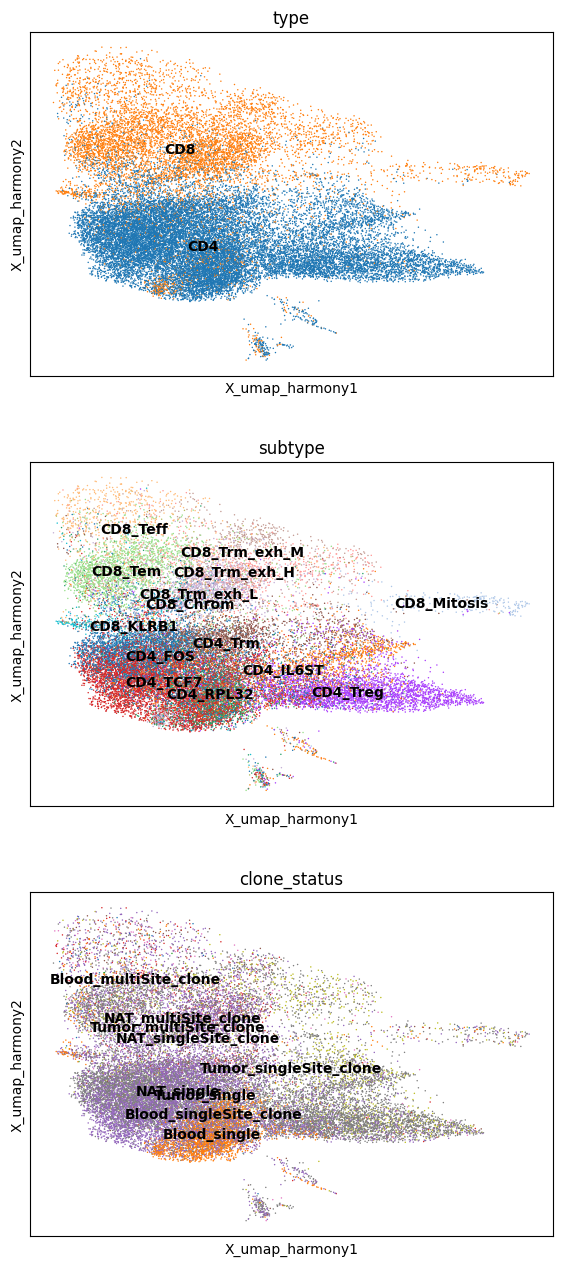

In [30]:
cols = [c for c in (
    'type',
    'subtype','cloned', 'in_two_tissue', 'clone_status'
) if c in mdata['gex'].obs]

sc.pl.embedding(mdata['gex'], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', legend_loc='on data',
                color=cols, ncols=1, )


In [31]:
# self CCA
dim_cca = 6
# cca = TCR_embedings.CCA(n_components=dim_cca) 
cca = TCR_embedings.rCCA(n_components=dim_cca, alpha_x=5, alpha_y=5,)

view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)

In [32]:
# Standardise canonical variates
        
# view_gene_c_train = scaler.fit_transform(view_gene_c_train)
# view_tcr_c_train = scaler.fit_transform(view_tcr_c_train)
# view_gene_c_test = scaler.fit_transform(view_gene_c_test)
# view_tcr_c_test = scaler.fit_transform(view_tcr_c_test)

# Combine into full-dataset arrays
view_gene_c = np.zeros((mdata.n_obs, dim_cca))
view_tcr_c = np.zeros((mdata.n_obs, dim_cca))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test

# Store canonical variate scores in mdata
for i in range(dim_cca):
    mdata['gex'].obs[f'DCCA_CV_{i}'] = view_gene_c[:, i]
    mdata['gex'].obs[f'DCCA_CV_TCR_{i}'] = view_tcr_c[:, i]

cv_list = []
for i in range(view_gene_c_train.shape[1]):
    mdata['gex'].obs['CV_score_'+str(i)] = view_tcr_c[:, i]
    cv_list.append('CV_score_'+str(i))
    
# Per-component correlations
print("Per-component correlations (train / test):")
for i in range(dim_cca):
    r_tr = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
    r_te = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
    print(f"  CC {i}: train {r_tr:.4f}  test {r_te:.4f}")

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape:  {view_gene_c_test.shape}")

Per-component correlations (train / test):
  CC 0: train 0.2377  test 0.2238
  CC 1: train 0.1901  test 0.1958
  CC 2: train 0.1148  test 0.0505
  CC 3: train 0.1078  test 0.0396
  CC 4: train 0.0973  test 0.0481
  CC 5: train 0.0985  test 0.0194

Train canonical variates shape: (19027, 6)
Test canonical variates shape:  (8132, 6)


In [33]:
view_gene_c_test.shape

(8132, 6)

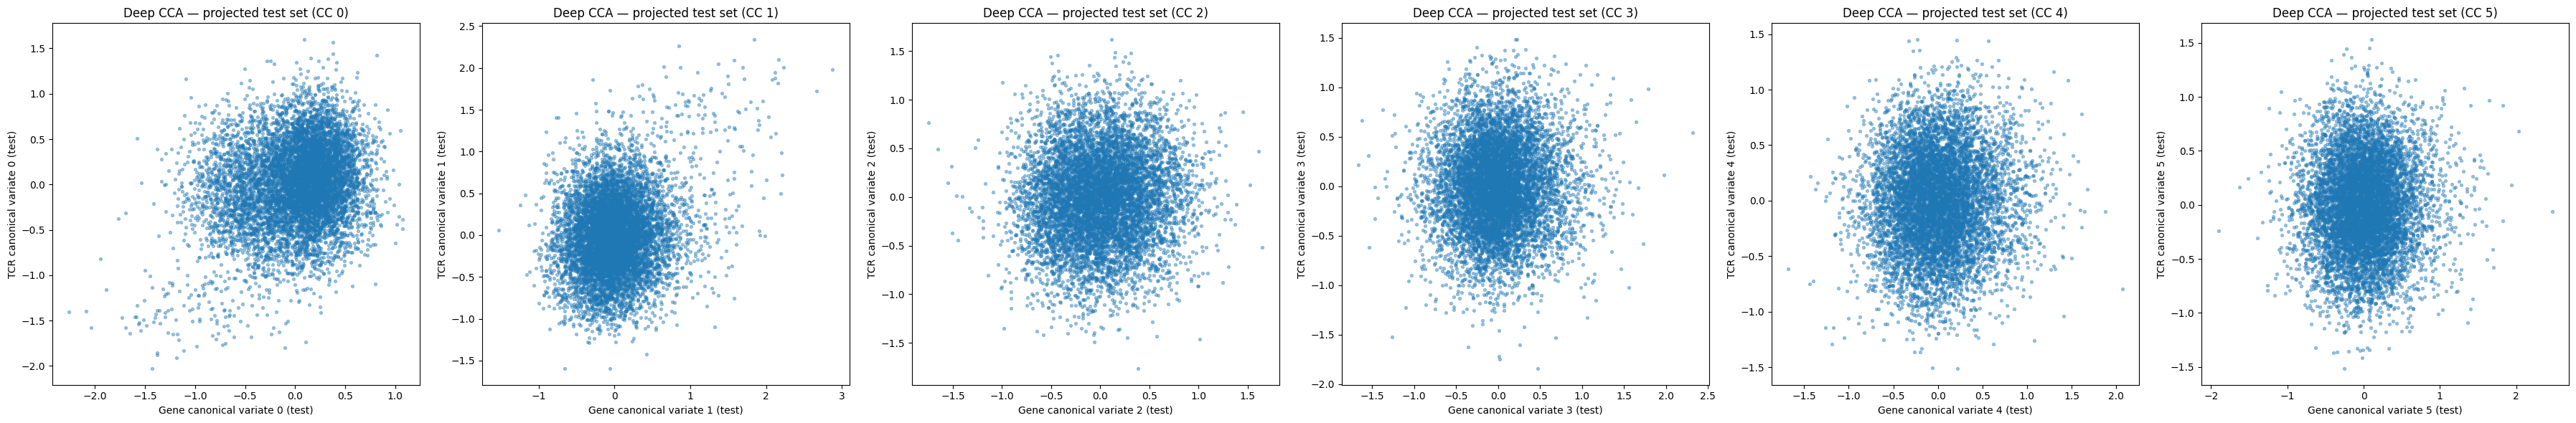

In [34]:
fig, axes = plt.subplots(1, dim_cca, figsize=(6 * dim_cca, 6))
if dim_cca == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.scatter(
        view_gene_c_test[:, i], view_tcr_c_test[:, i],
        alpha=0.4, s=8,
    )
    ax.set_xlabel(f'Gene canonical variate {i} (test)')
    ax.set_ylabel(f'TCR canonical variate {i} (test)')
    ax.set_title(f'Deep CCA — projected test set (CC {i})')

plt.tight_layout()
plt.show()

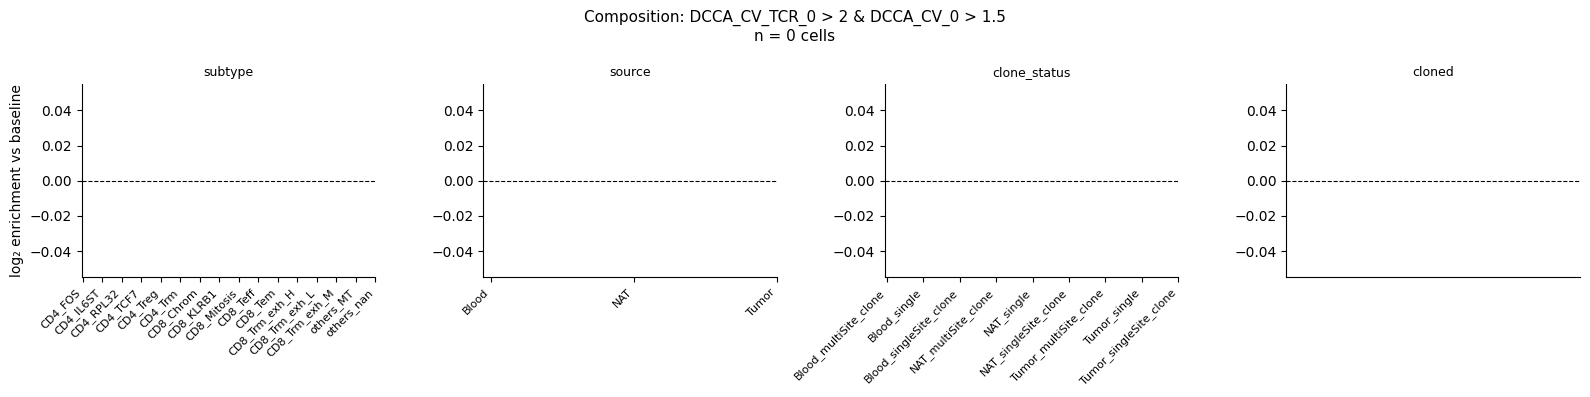


--- subtype ---
               n  fraction
subtype                   
CD4_FOS        0       NaN
CD4_IL6ST      0       NaN
CD4_RPL32      0       NaN
CD4_TCF7       0       NaN
CD4_Treg       0       NaN
CD4_Trm        0       NaN
CD8_Chrom      0       NaN
CD8_KLRB1      0       NaN
CD8_Mitosis    0       NaN
CD8_Teff       0       NaN
CD8_Tem        0       NaN
CD8_Trm_exh_H  0       NaN
CD8_Trm_exh_L  0       NaN
CD8_Trm_exh_M  0       NaN
others_MT      0       NaN
others_nan     0       NaN

--- source ---
        n  fraction
source             
Blood   0       NaN
NAT     0       NaN
Tumor   0       NaN

--- clone_status ---
                        n  fraction
clone_status                       
Blood_multiSite_clone   0       NaN
Blood_single            0       NaN
Blood_singleSite_clone  0       NaN
NAT_multiSite_clone     0       NaN
NAT_single              0       NaN
NAT_singleSite_clone    0       NaN
Tumor_multiSite_clone   0       NaN
Tumor_single            0       NaN

In [35]:
cca_k = 0
mask = (
    (mdata['gex'].obs['DCCA_CV_TCR_' + str(cca_k)] > 2) &
    (mdata['gex'].obs['DCCA_CV_' + str(cca_k)]     > 1.5)
)
mdata_sub = mdata[mask].copy()
composition_cols = ['subtype', 'source', 'clone_status', 'cloned']

plot_log2_enrichment(
    mdata_sub, mdata, composition_cols,
    title=f'Composition: DCCA_CV_TCR_{cca_k} > 2 & DCCA_CV_{cca_k} > 1.5\nn = {mask.sum()} cells',
)

### CCA 0

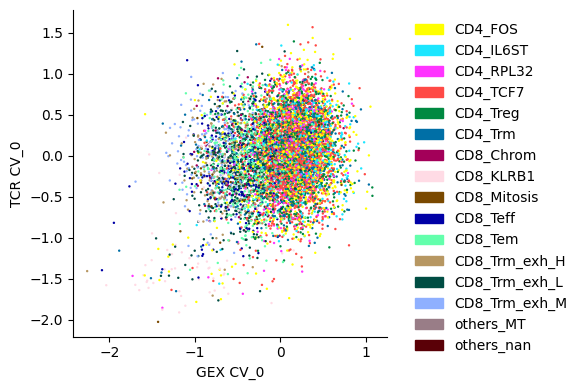

In [36]:
obs_select = 'subtype'
scatter_cca_colored(
    view_gene_c_test[:, cca_k], view_tcr_c_test[:, cca_k],
    obs_series=mdata.obs[obs_select][test_mask],
    cca_k=cca_k,
)

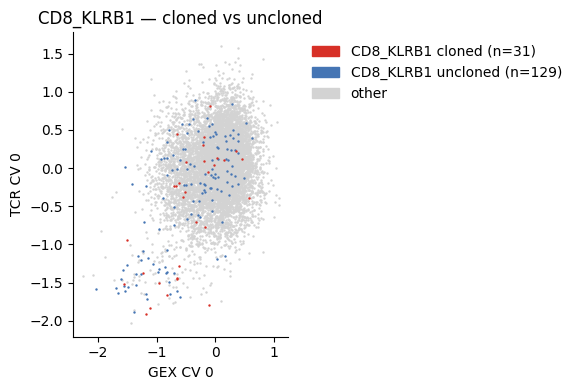

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

obs_select = 'subtype'
target_subtype = 'CD8_KLRB1'

values_subtype = mdata.obs[obs_select][test_mask]
values_cloned  = mdata.obs['cloned'][test_mask]

# Three groups: cloned=True, cloned=False, other (gray)
is_target  = values_subtype == target_subtype
is_cloned  = is_target & (values_cloned == True)
is_uncloned = is_target & (values_cloned == False)
is_other   = ~is_target

color_cloned   = '#d73027'  # red
color_uncloned = '#4575b4'  # blue
color_other    = '#d3d3d3'  # gray

colors = np.where(is_cloned, color_cloned,
         np.where(is_uncloned, color_uncloned, color_other))

fig, ax = plt.subplots(figsize=(6, 4))

# Draw in layers: other → uncloned → cloned (top)
for mask_layer, color, zorder in [
    (is_other,    color_other,    1),
    (is_uncloned, color_uncloned, 2),
    (is_cloned,   color_cloned,   3),
]:
    ax.scatter(
        view_gene_c_test[mask_layer, cca_k],
        view_tcr_c_test[mask_layer, cca_k],
        c=color, linewidths=0, s=3, zorder=zorder
    )

n_cloned   = is_cloned.sum()
n_uncloned = is_uncloned.sum()

handles = [
    mpatches.Patch(color=color_cloned,   label=f'CD8_KLRB1 cloned (n={n_cloned})'),
    mpatches.Patch(color=color_uncloned, label=f'CD8_KLRB1 uncloned (n={n_uncloned})'),
    mpatches.Patch(color=color_other,    label='other'),
]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=False)
ax.set_xlabel(f'GEX CV {cca_k}')
ax.set_ylabel(f'TCR CV {cca_k}')
ax.set_title(f'CD8_KLRB1 — cloned vs uncloned')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [38]:
mask = (mdata['gex'].obs['subtype'].str == 'CD8_KLRB1')
mask

False

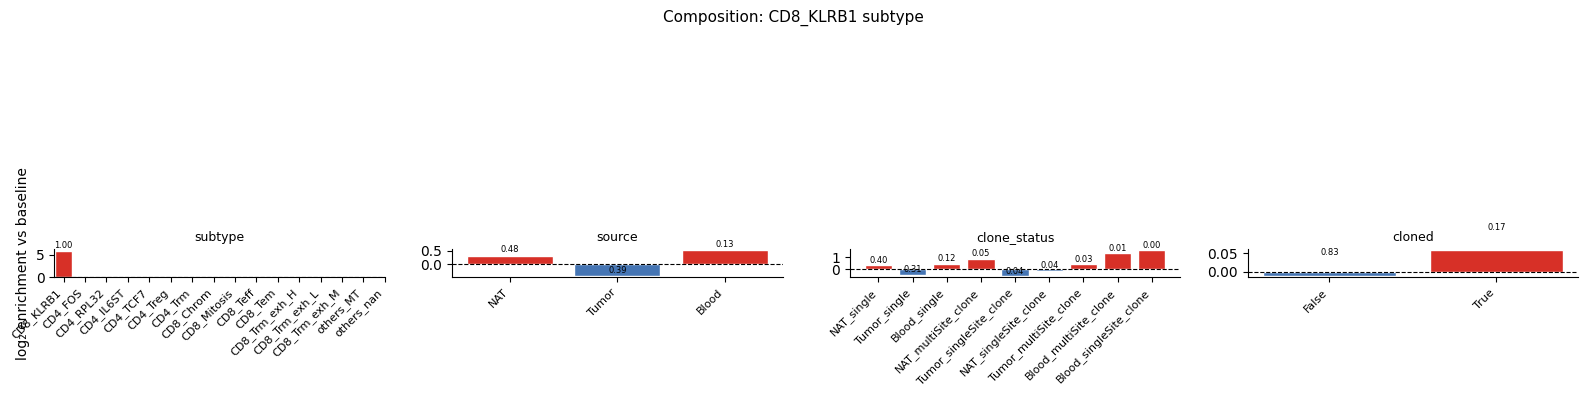


--- subtype ---
                 n  fraction
subtype                     
CD8_KLRB1      447       1.0
CD4_FOS          0       0.0
CD4_RPL32        0       0.0
CD4_IL6ST        0       0.0
CD4_TCF7         0       0.0
CD4_Treg         0       0.0
CD4_Trm          0       0.0
CD8_Chrom        0       0.0
CD8_Mitosis      0       0.0
CD8_Teff         0       0.0
CD8_Tem          0       0.0
CD8_Trm_exh_H    0       0.0
CD8_Trm_exh_L    0       0.0
CD8_Trm_exh_M    0       0.0
others_MT        0       0.0
others_nan       0       0.0

--- source ---
          n  fraction
source               
NAT     216     0.483
Tumor   173     0.387
Blood    58     0.130

--- clone_status ---
                          n  fraction
clone_status                         
NAT_single              179     0.400
Tumor_single            139     0.311
Blood_single             54     0.121
NAT_multiSite_clone      21     0.047
Tumor_singleSite_clone   20     0.045
NAT_singleSite_clone     16     0.036
Tumor_mul

In [39]:
cca_k = 0
mdata_sub = mdata[mdata['gex'].obs['subtype'] == 'CD8_KLRB1'].copy()
composition_cols = ['subtype', 'source', 'clone_status', 'cloned']

plot_log2_enrichment(mdata_sub, mdata, composition_cols, title='Composition: CD8_KLRB1 subtype')

## CCA 1

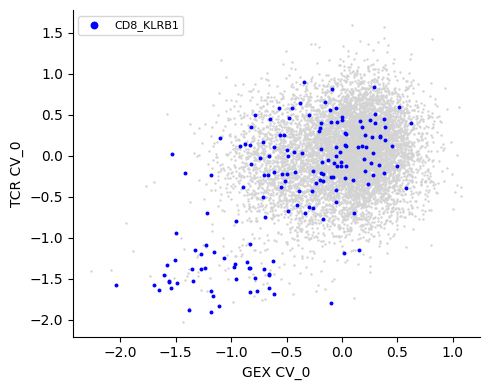

In [40]:
cats = mdata.obs[obs_select][test_mask].cat.categories
palette = dict(zip(cats, sc.pl.palettes.default_102[:len(cats)]))

target = 'CD8_KLRB1'
labels = mdata.obs[obs_select][test_mask]

# gray for all, highlight color for target
colors = labels.map(lambda x: palette.get(target, 'red') if x == target else '#d3d3d3')

fig, ax = plt.subplots(figsize=(5, 4))

# plot gray background first
bg_mask = labels != target
ax.scatter(
    view_gene_c_test[bg_mask, cca_k], view_tcr_c_test[bg_mask, cca_k],
    c='#d3d3d3', linewidths=0, s=3, zorder=1
)

# plot highlight on top
fg_mask = labels == target
ax.scatter(
    view_gene_c_test[fg_mask, cca_k], view_tcr_c_test[fg_mask, cca_k],
    c='blue', linewidths=0, s=8,
    zorder=2, label=target
)

ax.set_xlabel(f'GEX CV_{cca_k}')
ax.set_ylabel(f'TCR CV_{cca_k}')
ax.legend(fontsize=8, markerscale=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### CCA_2

In [41]:
mdata['gex'].obs['subtype']

LT1_CACATAGAGTGTACCT-1     CD4_FOS
LN3_CTTAGGATCGCGCCAA-2    CD8_Teff
LN1_CCTATTAAGTCTCAAC-1     CD4_Trm
LN3_GTAACTGAGTTAGGTA-2    CD4_TCF7
LN3_GACGCGTTCAGTGTTG-2     CD4_FOS
                            ...   
RB3_TTGAACGGTCCTAGCG-1     CD4_Trm
RB3_TTGACTTTCTATCCTA-1    CD4_Treg
RB3_TTTACTGGTAAGGATT-1    CD4_Treg
RB3_TTTATGCAGTTTGCGT-1    CD8_Teff
RB3_TTTGGTTTCAACACCA-1    CD4_Treg
Name: subtype, Length: 27159, dtype: category
Categories (14, object): ['CD4_FOS', 'CD4_IL6ST', 'CD4_RPL32', 'CD4_TCF7', ..., 'CD8_Tem', 'CD8_Trm_exh_H', 'CD8_Trm_exh_L', 'CD8_Trm_exh_M']

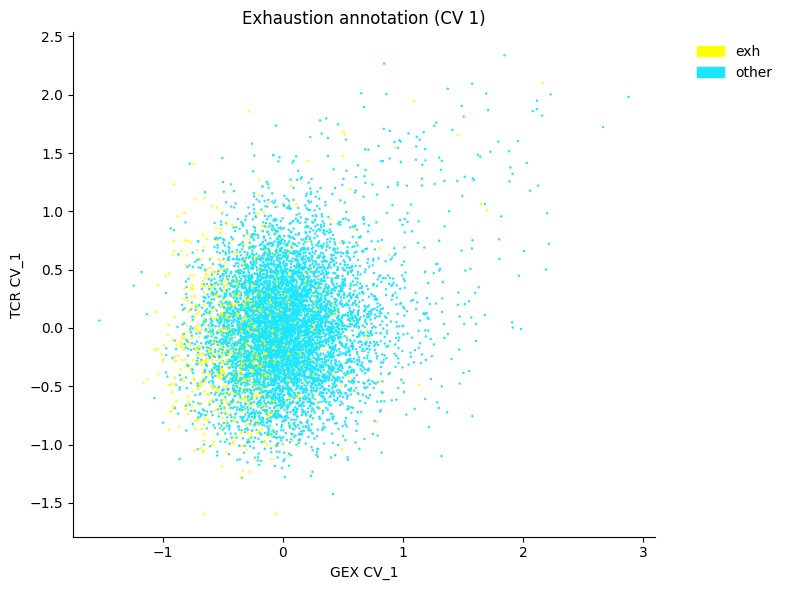

In [42]:
def classify_annotation(label):
    return 'exh' if 'exh' in str(label) else 'other'

mdata['gex'].obs['T_subset'] = (
    mdata['gex'].obs['subtype']
    .apply(classify_annotation)
    .astype('category')
)

i = 1
scatter_cca_colored(
    view_gene_c_test[:, i], view_tcr_c_test[:, i],
    obs_series=mdata['gex'].obs['T_subset'][test_mask],
    cca_k=i,
    title='Exhaustion annotation (CV 1)',
    figsize=(8, 6),
)

### CCA 3

In [43]:
## DEG for these

target_gene  = 'TRBV30'
v_call_col   = 'VDJ_1_v_call'
subtype_col  = 'subtype'

# work on gex modality
adata = mdata['gex'].copy()
adata.obs[v_call_col] = mdata.obs[v_call_col]

# only use test set cells
adata = adata[test_mask].copy()

results = {}

for st in adata.obs[subtype_col].dropna().unique():

    # cells of this subtype
    st_mask   = adata.obs[subtype_col] == st

    # within subtype: TRBV30 vs rest
    trbv_mask = (adata.obs[v_call_col] == target_gene) & st_mask
    rest_mask = (adata.obs[v_call_col] != target_gene) & st_mask

    n_trbv = trbv_mask.sum()
    n_rest = rest_mask.sum()

    if n_trbv < 3 or n_rest < 3:
        print(f'Skipping {st}: TRBV30 n={n_trbv}, rest n={n_rest}')
        continue

    print(f'Running DEG for {st}: TRBV30 n={n_trbv} vs rest n={n_rest}')

    # label group
    adata.obs['deg_group'] = 'skip'
    adata.obs.loc[trbv_mask, 'deg_group'] = 'TRBV30'
    adata.obs.loc[rest_mask, 'deg_group'] = 'rest'

    # subset to just these two groups
    sub = adata[adata.obs['deg_group'] != 'skip'].copy()

    sc.tl.rank_genes_groups(
        sub,
        groupby    = 'deg_group',
        groups     = ['TRBV30'],
        reference  = 'rest',
        method     = 'wilcoxon',
        key_added  = 'deg_trbv30',
        pts        = True,
    )

    # extract results
    deg_df = sc.get.rank_genes_groups_df(
        sub,
        group   = 'TRBV30',
        key     = 'deg_trbv30',
        pval_cutoff  = 0.1,
    ).assign(subtype=st)

    results[st] = deg_df

# concatenate all subtypes
df_deg = pd.concat(results.values(), ignore_index=True)
df_deg = df_deg.sort_values(['subtype', 'pvals_adj'])

df_deg.head()

Running DEG for CD8_Teff: TRBV30 n=4 vs rest n=225
Running DEG for CD4_Trm: TRBV30 n=22 vs rest n=737
Running DEG for CD8_Trm_exh_H: TRBV30 n=4 vs rest n=261
Running DEG for CD8_Trm_exh_L: TRBV30 n=20 vs rest n=520
Running DEG for CD4_TCF7: TRBV30 n=54 vs rest n=1834
Running DEG for CD4_Treg: TRBV30 n=22 vs rest n=1008
Running DEG for CD8_Tem: TRBV30 n=10 vs rest n=576
Running DEG for CD4_FOS: TRBV30 n=30 vs rest n=1225
Running DEG for CD4_IL6ST: TRBV30 n=12 vs rest n=507
Skipping CD8_Mitosis: TRBV30 n=2, rest n=90
Running DEG for CD8_Trm_exh_M: TRBV30 n=4 vs rest n=180
Skipping CD8_KLRB1: TRBV30 n=2, rest n=158
Running DEG for CD8_Chrom: TRBV30 n=8 vs rest n=80
Running DEG for CD4_RPL32: TRBV30 n=17 vs rest n=520


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,subtype


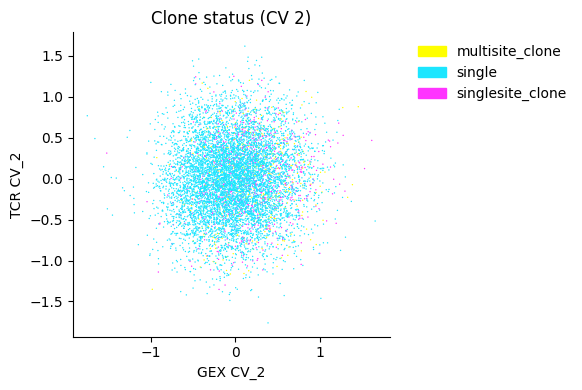

In [44]:
obs_col = mdata['gex'].obs['clone_status'].astype(str)
conditions = [
    obs_col.str.endswith('multiSite_clone'),
    obs_col.str.endswith('singleSite_clone'),
    obs_col.str.endswith('single'),
]
choices = ['multisite_clone', 'singlesite_clone', 'single']
mdata['gex'].obs['T_set'] = np.select(conditions, choices, default='other')
mdata['gex'].obs['T_set'] = mdata['gex'].obs['T_set'].astype('category')

i = 2
scatter_cca_colored(
    view_gene_c_test[:, i], view_tcr_c_test[:, i],
    obs_series=mdata['gex'].obs['T_set'][test_mask],
    cca_k=i,
    title='Clone status (CV 2)',
    s=1,
)


=== Count ===
subtype           CD4_FOS  CD4_IL6ST  CD4_RPL32  CD4_TCF7  CD4_Treg  CD4_Trm  \
T_set                                                                          
multisite_clone       145         23         45        89        74      156   
single               3796       1506       1632      6025      2864     2022   
singlesite_clone      286        180         86       147       485      449   
Total                4227       1709       1763      6261      3423     2627   

subtype           CD8_Chrom  CD8_KLRB1  CD8_Mitosis  CD8_Teff  CD8_Tem  \
T_set                                                                    
multisite_clone          17         38           18       158      229   
single                  242        372          203       489     1319   
singlesite_clone         40         37           60       147      337   
Total                   299        447          281       794     1885   

subtype           CD8_Trm_exh_H  CD8_Trm_exh_L  CD8_Trm_exh_

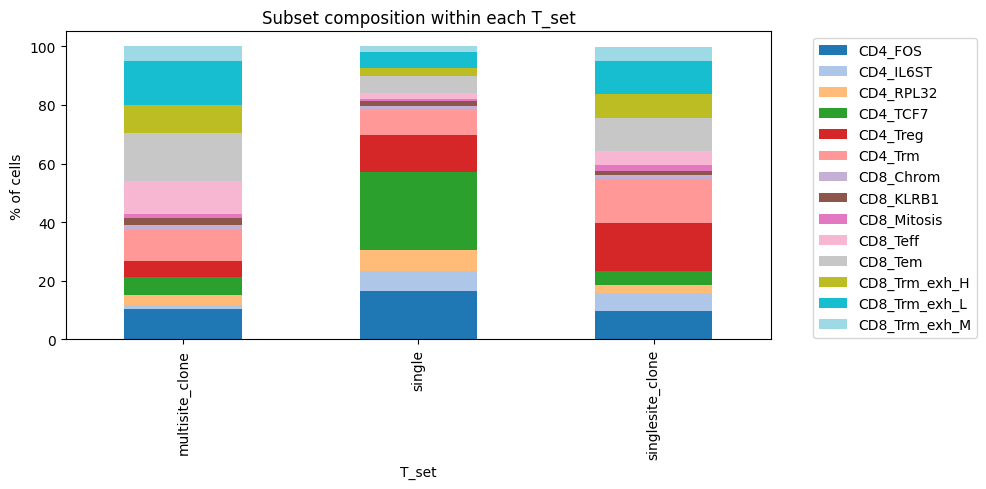

In [45]:
import pandas as pd

# Cross-tabulation of subset composition within each T_set
crosstab = pd.crosstab(
    mdata['gex'].obs['T_set'],
    mdata['gex'].obs['subtype'],
    margins=True,
    margins_name='Total'
)

# Normalized by row (proportion within each T_set)
crosstab_pct = pd.crosstab(
    mdata['gex'].obs['T_set'],
    mdata['gex'].obs['subtype'],
    normalize='index'
).round(3) * 100

print("=== Count ===")
print(crosstab)
print("\n=== % within T_set ===")
print(crosstab_pct)


crosstab_pct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
plt.ylabel('% of cells')
plt.xlabel('T_set')
plt.title('Subset composition within each T_set')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [46]:
corr_train, corr_test = TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.2377          0.2238          0.0138         
Component 2      0.1901          0.1958          -0.0056        
Component 3      0.1148          0.0505          0.0643         
Component 4      0.1078          0.0396          0.0682         
Component 5      0.0973          0.0481          0.0492         
Component 6      0.0985          0.0194          0.0790         


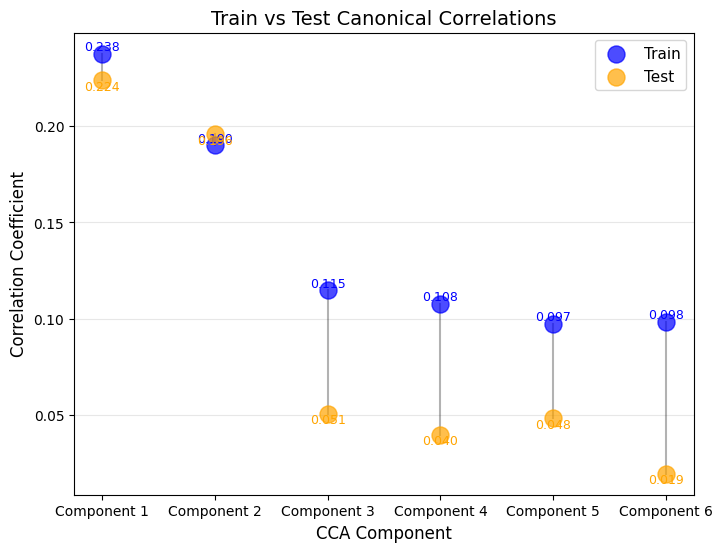

In [47]:
ax = TCR_embedings.plot_train_test_corr(corr_train, corr_test)
# ax.set_ylim(0, 1)

In [48]:
# mdata['gex'].obs['Annotation_minor_subset'] = (
#     mdata['gex'].obs['Annotation_minor_subset']
#     .cat.remove_unused_categories()
# )

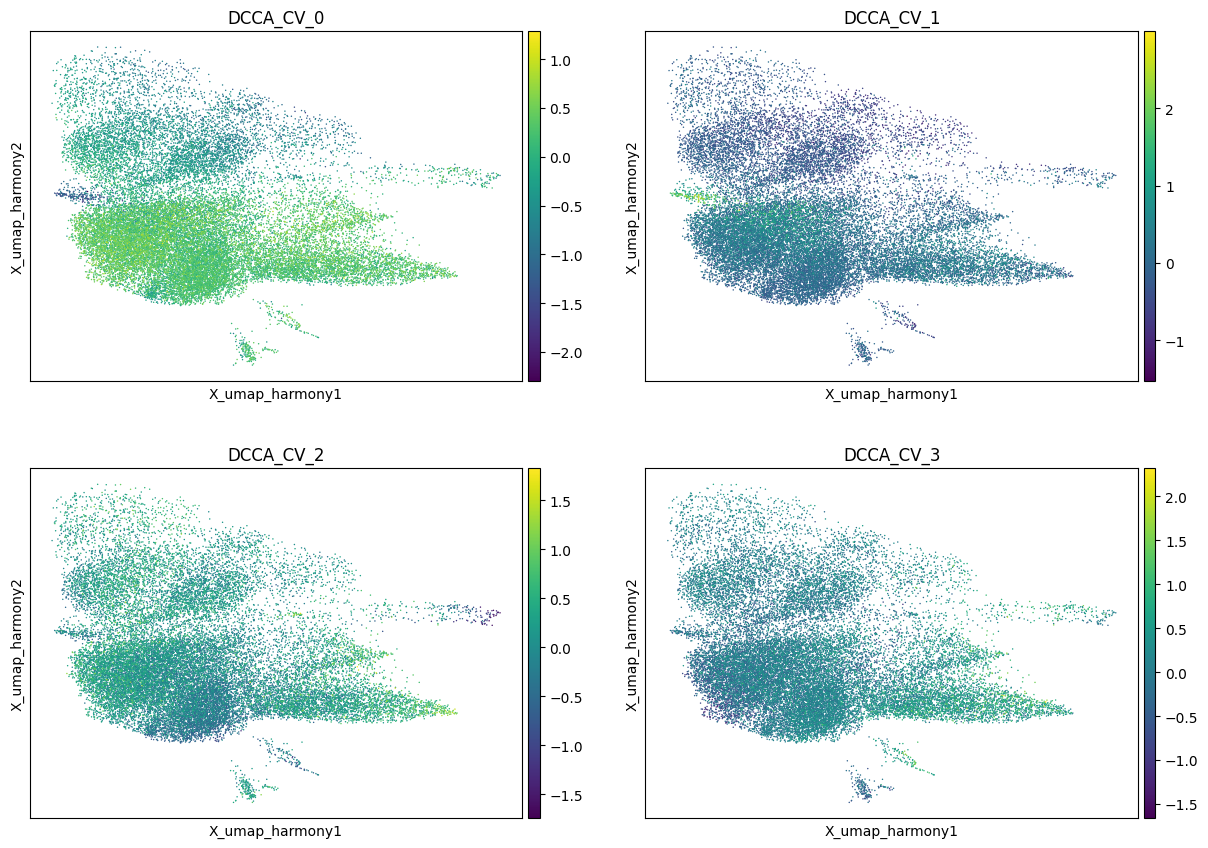

In [49]:
cols = [c for c in (
    'DCCA_CV_0',
    'DCCA_CV_1',
    'DCCA_CV_2',
    'DCCA_CV_3',
    
) if c in mdata['gex'].obs]

sc.pl.embedding(mdata['gex'], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=cols, ncols=2)

## Align CCA score with obs

In [50]:
mdata

MuData object with n_obs × n_vars = 27159 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'vdjdb_match', 'vdjdb_label', 'set'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	27159 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status', 'DCCA_CV_0', 'DCCA_CV_TCR_0', 'DCCA_CV_1', 'DCCA_CV_TCR_1', 'DCCA_CV_2', 'DCCA_CV_TCR_2', 'DCCA_CV_3', 'DCCA_CV_TCR_3', 'DCCA_CV_4', 'DCCA_CV_TCR_4', 'DCCA_CV_5', 'DCCA_CV_TCR_5', 'CV_score_0', 'CV_score_1', 'CV_score_2', 'CV_score_3', 'CV_score_4', 'CV_score_5', 'T_subset', 'T_set'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap', 'clone_status_colors'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	27159 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [51]:
# Step 1 — Kruskal-Wallis / Point-biserial: does this column matter at all?

from scipy.stats import kruskal, pointbiserialr
import pandas as pd

composition_cols = ['type', 'subtype', 'in_two_tissue', 'clone_status', 'cloned', 'source']
for obs in composition_cols:
    mdata['gex'].obs[obs] = mdata.obs[obs]
    
records = []
# CV_from = "DCCA_CV_"
CV_from = "DCCA_CV_TCR_"


for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()
    idx = scores.index

    for c in composition_cols:
        cats = mdata.obs.loc[idx, c].dropna()
        shared_idx = scores.index.intersection(cats.index)
        s = scores.loc[shared_idx]
        g = cats.loc[shared_idx]

        unique_cats = g.unique()

        if len(unique_cats) == 2:
            # binary → point-biserial r
            binary = (g == unique_cats[0]).astype(int)
            r, p = pointbiserialr(binary, s)
            records.append(dict(cv=col, obs_col=c, test='pointbiserial',
                                statistic=r, pval=p, categories=list(unique_cats)))

        elif len(unique_cats) > 2:
            # multi-category → Kruskal-Wallis H
            groups = [s[g == cat].values for cat in unique_cats]
            groups = [g for g in groups if len(g) > 1]
            if len(groups) >= 2:
                H, p = kruskal(*groups)
                records.append(dict(cv=col, obs_col=c, test='kruskal',
                                    statistic=H, pval=p, categories=list(unique_cats)))

df_stats = pd.DataFrame(records)

# FDR correction
from statsmodels.stats.multitest import multipletests
_, df_stats['pval_fdr'], _, _ = multipletests(df_stats['pval'], method='fdr_bh')
df_stats = df_stats.sort_values(['cv', 'pval_fdr'])
print(df_stats[['cv', 'obs_col', 'test', 'statistic', 'pval', 'pval_fdr']])

               cv        obs_col           test   statistic           pval  \
0   DCCA_CV_TCR_0           type  pointbiserial    0.166302  1.185986e-167   
1   DCCA_CV_TCR_0        subtype        kruskal  711.152306  1.422000e-143   
4   DCCA_CV_TCR_0         cloned  pointbiserial   -0.048424   1.409339e-15   
3   DCCA_CV_TCR_0   clone_status        kruskal   82.254695   1.717537e-14   
2   DCCA_CV_TCR_0  in_two_tissue  pointbiserial    0.037420   6.887361e-10   
5   DCCA_CV_TCR_0         source        kruskal    7.828906   1.995146e-02   
7   DCCA_CV_TCR_1        subtype        kruskal  386.604099   1.505001e-74   
6   DCCA_CV_TCR_1           type  pointbiserial    0.063170   2.001640e-25   
9   DCCA_CV_TCR_1   clone_status        kruskal   22.780475   3.657826e-03   
10  DCCA_CV_TCR_1         cloned  pointbiserial   -0.017061   4.927847e-03   
11  DCCA_CV_TCR_1         source        kruskal    6.807642   3.324599e-02   
8   DCCA_CV_TCR_1  in_two_tissue  pointbiserial    0.007306   2.

In [52]:
# Step 2 — Spearman per category label: which specific label drives it?
from scipy.stats import spearmanr

records_cat = []

for i in range(3):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    for c in composition_cols:
        cats = mdata.obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(cats.index)

        for cat_val in cats.loc[shared].unique():
            binary = (cats.loc[shared] == cat_val).astype(int)
            r, p = spearmanr(scores.loc[shared], binary)
            records_cat.append(dict(cv=col, obs_col=c, category=cat_val,
                                    spearman_r=r, pval=p))

df_cat = pd.DataFrame(records_cat)
_, df_cat['pval_fdr'], _, _ = multipletests(df_cat['pval'], method='fdr_bh')
df_cat = df_cat.sort_values('spearman_r', key=abs, ascending=False)
print(df_cat.head(20))

               cv       obs_col       category  spearman_r           pval  \
0   DCCA_CV_TCR_0          type            CD4    0.156551  1.456294e-148   
1   DCCA_CV_TCR_0          type            CD8   -0.156551  1.456294e-148   
33  DCCA_CV_TCR_1          type            CD8   -0.082293   4.965952e-42   
32  DCCA_CV_TCR_1          type            CD4    0.082293   4.965952e-42   
6   DCCA_CV_TCR_0       subtype  CD8_Trm_exh_L   -0.076111   3.468477e-36   
8   DCCA_CV_TCR_0       subtype        CD8_Tem   -0.064370   2.438593e-26   
13  DCCA_CV_TCR_0       subtype      CD8_KLRB1   -0.059447   1.070761e-22   
45  DCCA_CV_TCR_1       subtype      CD8_KLRB1    0.059170   1.684237e-22   
3   DCCA_CV_TCR_0       subtype       CD8_Teff   -0.053875   6.411524e-19   
7   DCCA_CV_TCR_0       subtype  CD8_Trm_exh_H   -0.051184   3.168443e-17   
5   DCCA_CV_TCR_0       subtype       CD4_TCF7    0.050599   7.199893e-17   
43  DCCA_CV_TCR_1       subtype  CD8_Trm_exh_M   -0.049905   1.885209e-16   

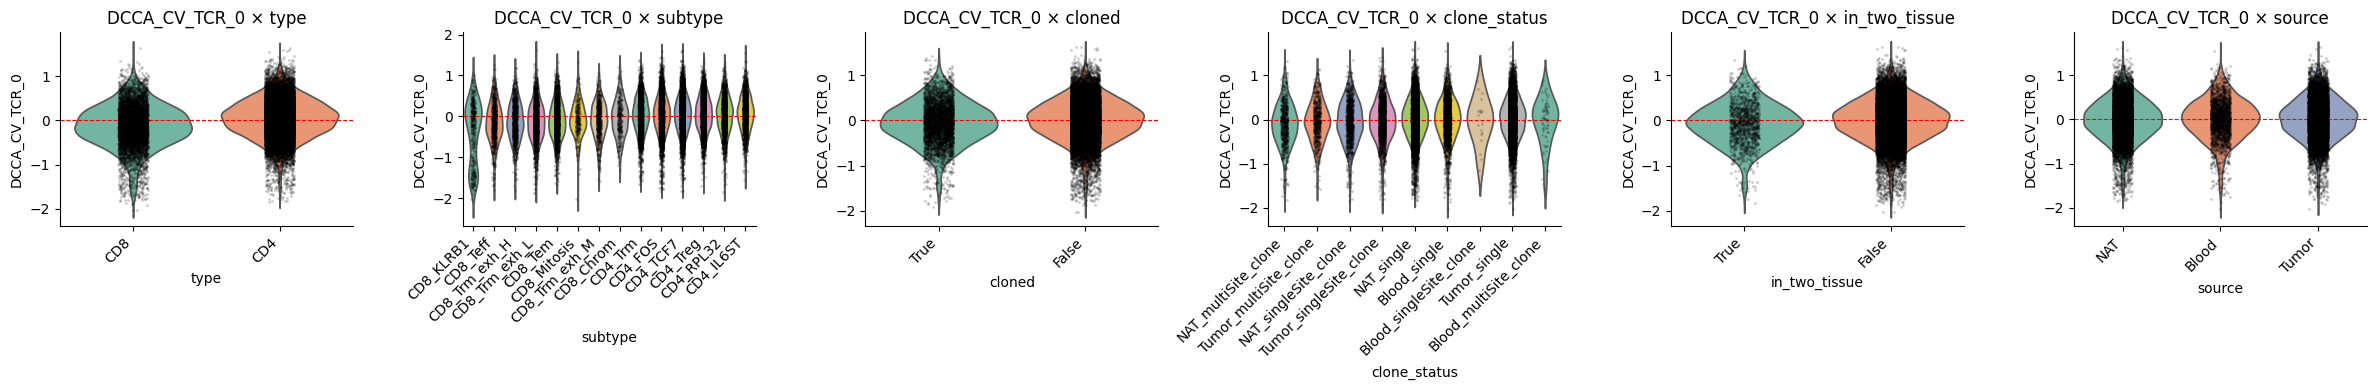

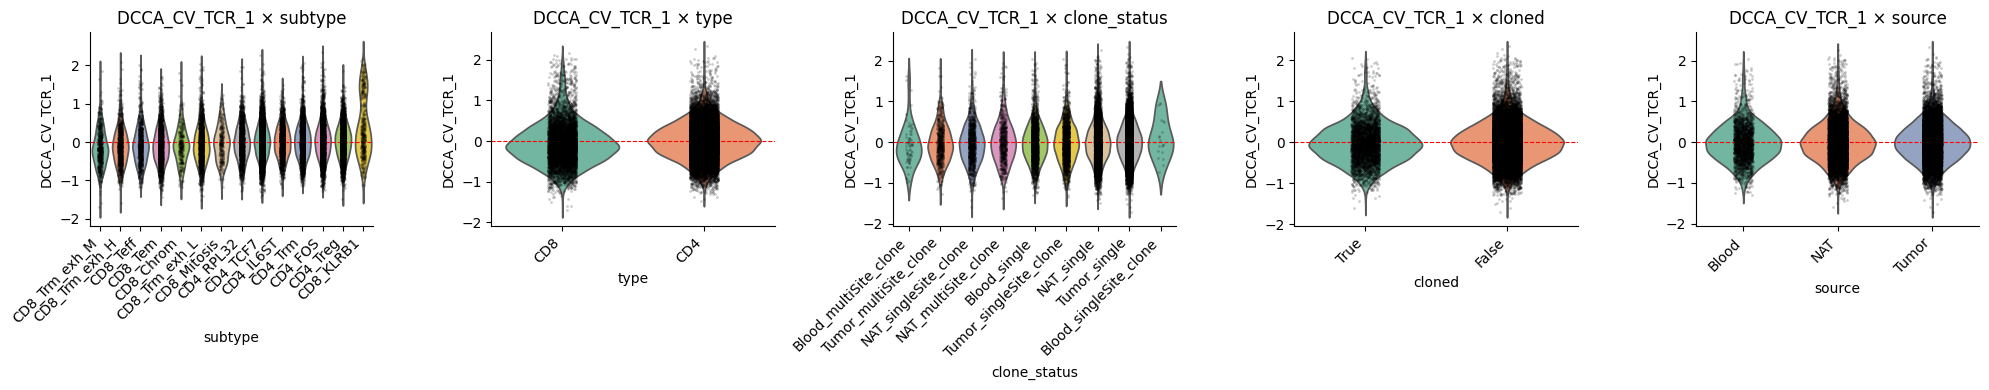

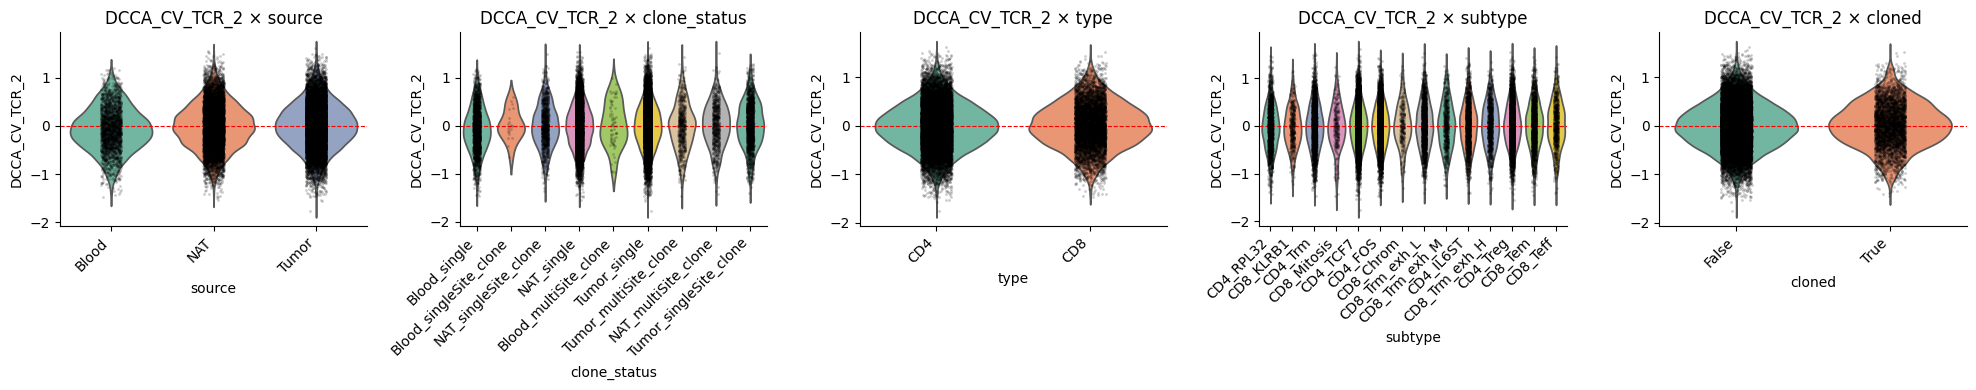

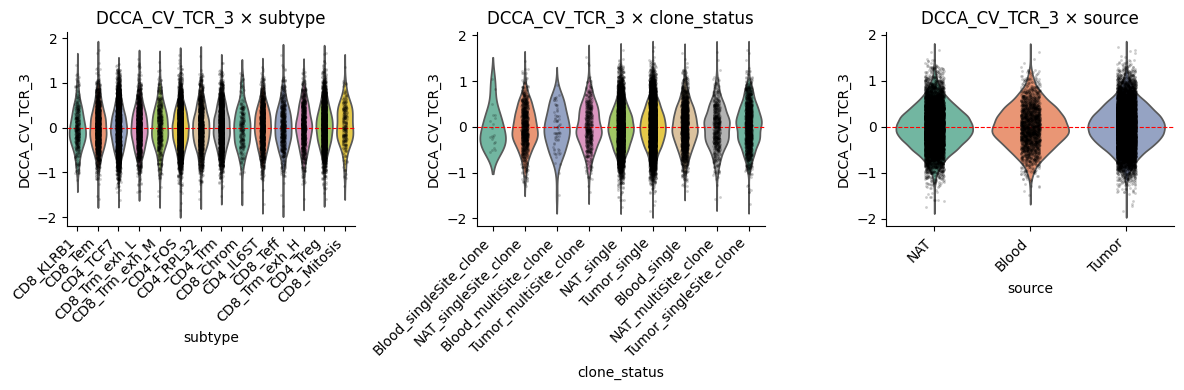

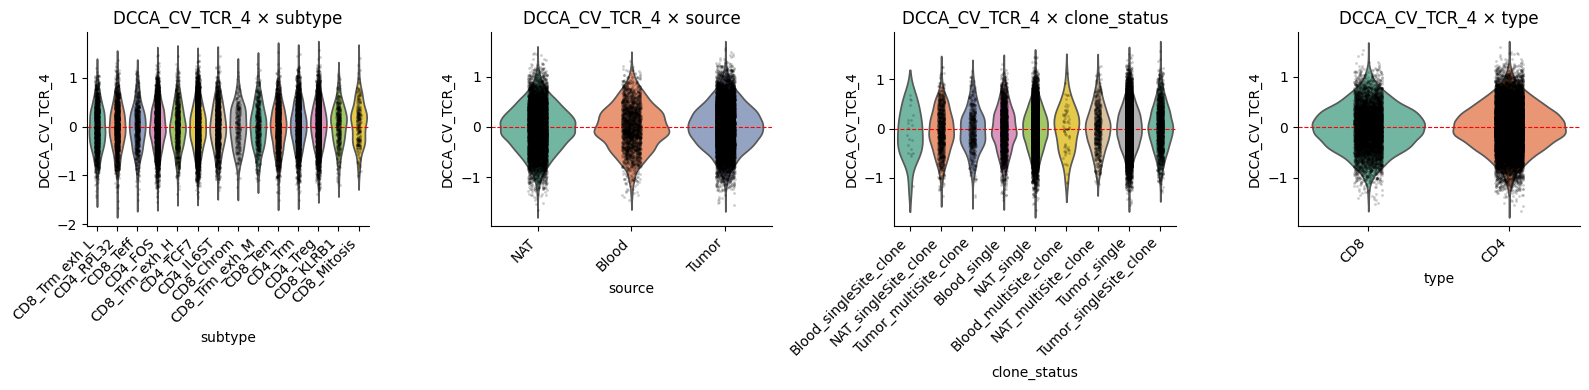

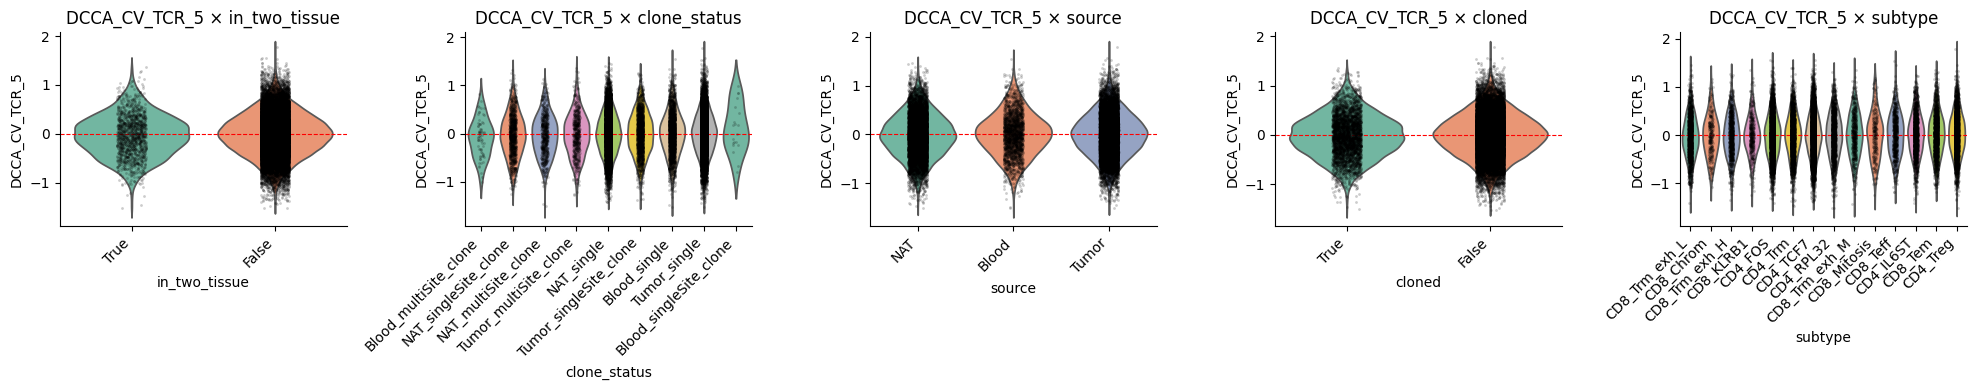

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# pick significant columns per CV from df_stats
sig = df_stats[df_stats['pval_fdr'] < 0.05]

for i in range(dim_cca):
    col = CV_from + str(i)
    sig_cols = sig[sig['cv'] == col]['obs_col'].tolist()

    if not sig_cols:
        continue

    fig, axes = plt.subplots(1, len(sig_cols), figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        mdata['gex'].obs[c] = mdata['gex'].obs[c].astype('category').cat.remove_unused_categories()
        plot_df = mdata['gex'].obs[[col, c]].dropna()
        order = plot_df.groupby(c)[col].median().sort_values().index

        sns.violinplot(data=plot_df, x=c, y=col, order=order,
                       inner=None, palette='Set2', ax=ax)
        sns.stripplot(data=plot_df, x=c, y=col, order=order,
                      color='black', alpha=0.2, size=2, ax=ax)
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
        ax.set_title(f'{col} × {c}')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.spines[['top', 'right']].set_visible(False)
        # ax.set_ylim([-0.5, 0.5])

    plt.tight_layout()
    #plt.savefig(f'{col}_category_association.png', bbox_inches='tight')
    plt.show()

In [54]:
## pairwise subset comparison
from scipy.stats import mannwhitneyu
from itertools import combinations

records_posthoc = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    # only run on columns that passed Step 1 FDR
    sig_cols = df_stats[
        (df_stats['cv'] == col) & (df_stats['pval_fdr'] < 0.05)
    ]['obs_col'].tolist()

    for c in sig_cols:
        cats = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(cats.index)
        s = scores.loc[shared]
        g = cats.loc[shared]

        unique_cats = g.unique()

        for cat_a, cat_b in combinations(unique_cats, 2):
            vals_a = s[g == cat_a].values
            vals_b = s[g == cat_b].values

            if len(vals_a) < 3 or len(vals_b) < 3:
                continue

            U, p = mannwhitneyu(vals_a, vals_b, alternative='two-sided')

            # effect size: rank-biserial correlation
            n_a, n_b = len(vals_a), len(vals_b)
            rbc = 1 - (2 * U) / (n_a * n_b)

            records_posthoc.append(dict(
                cv       = col,
                obs_col  = c,
                cat_a    = cat_a,
                cat_b    = cat_b,
                U        = U,
                pval     = p,
                rbc      = rbc,   # effect size: -1 to +1
            ))

df_posthoc = pd.DataFrame(records_posthoc)
_, df_posthoc['pval_fdr'], _, _ = multipletests(df_posthoc['pval'], method='fdr_bh')
df_posthoc = df_posthoc.sort_values('pval_fdr')
print(df_posthoc[df_posthoc['pval_fdr'] < 0.05])

                cv       obs_col                cat_a          cat_b  \
0    DCCA_CV_TCR_0          type                  CD4            CD8   
37   DCCA_CV_TCR_0       subtype             CD4_TCF7  CD8_Trm_exh_L   
52   DCCA_CV_TCR_0       subtype        CD8_Trm_exh_L       CD4_Treg   
224  DCCA_CV_TCR_1          type                  CD4            CD8   
49   DCCA_CV_TCR_0       subtype        CD8_Trm_exh_L      CD4_IL6ST   
..             ...           ...                  ...            ...   
401  DCCA_CV_TCR_3       subtype              CD4_FOS  CD8_Trm_exh_H   
677  DCCA_CV_TCR_5  clone_status  NAT_multiSite_clone   Tumor_single   
534  DCCA_CV_TCR_4       subtype              CD4_FOS    CD8_Mitosis   
263  DCCA_CV_TCR_1        source                Tumor          Blood   
179  DCCA_CV_TCR_1       subtype        CD8_Trm_exh_L  CD8_Trm_exh_H   

              U           pval       rbc       pval_fdr  
0    86205682.5  9.087084e-147 -0.205240  7.178797e-144  
37    6973361.0   1

In [55]:
# for i in range(dim_cca):
#     col = CV_from + str(i)
#     sig_cols = df_posthoc[
#         (df_posthoc['cv'] == col) & (df_posthoc['pval_fdr'] < 0.05)
#     ]['obs_col'].unique()

#     for c in sig_cols:
#         sub = df_posthoc[(df_posthoc['cv'] == col) & (df_posthoc['obs_col'] == c)]
#         cats = pd.Index(
#             pd.concat([sub['cat_a'], sub['cat_b']]).unique()
#         )

#         # pivot effect size (rbc) into a square matrix
#         mat = pd.DataFrame(np.nan, index=cats, columns=cats)
#         for _, row in sub.iterrows():
#             # mat.loc[row.cat_a, row.cat_b] = row.rbc
#             # mat.loc[row.cat_b, row.cat_a] = -row.rbc  # antisymmetric
            
#             mat.loc[row.cat_a, row.cat_b] = abs(row.rbc)
#             mat.loc[row.cat_b, row.cat_a] = abs(row.rbc)  # symmetric
            
            
#         np.fill_diagonal(mat.values, 0)

#         # significance mask
#         sig_mat = pd.DataFrame(False, index=cats, columns=cats)
#         for _, row in sub.iterrows():
#             sig = row.pval_fdr < 0.05
#             sig_mat.loc[row.cat_a, row.cat_b] = sig
#             sig_mat.loc[row.cat_b, row.cat_a] = sig

#         fig, ax = plt.subplots(figsize=(0.6 * len(cats) + 2, 0.6 * len(cats) + 2))
#         sns.heatmap(mat.astype(float), annot=True, fmt='.2f', center=0,
#                     cmap='RdBu_r', vmin= 0, vmax=1,
#                     mask=~sig_mat,         # grey out non-significant pairs
#                     linewidths=0.5, ax=ax)
#         ax.set_title(f'{col} × {c}\nrank-biserial correlation (FDR<0.05 only)', fontsize=10)
#         plt.tight_layout()
#         #plt.savefig(f'{col}_{c}_posthoc_heatmap.png', bbox_inches='tight')
#         plt.show()

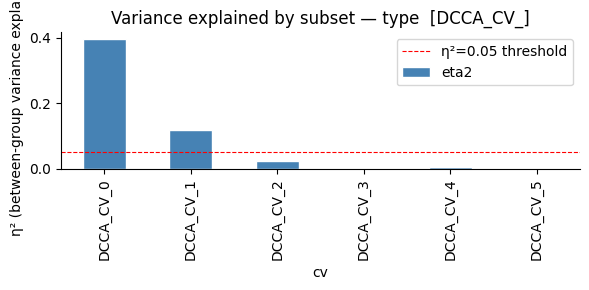

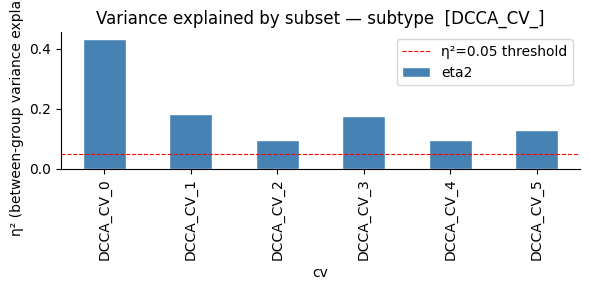

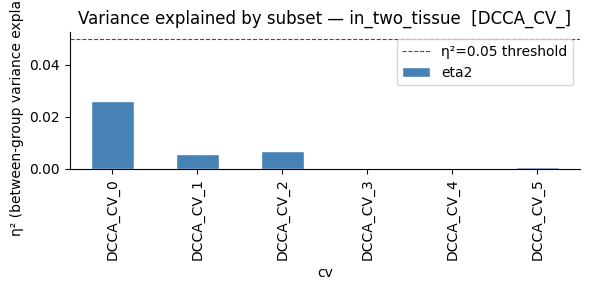

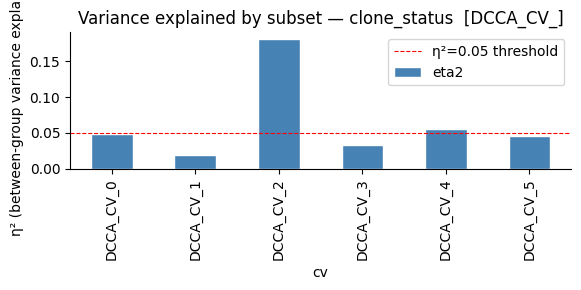

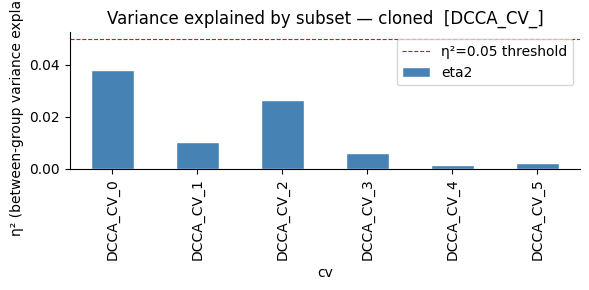

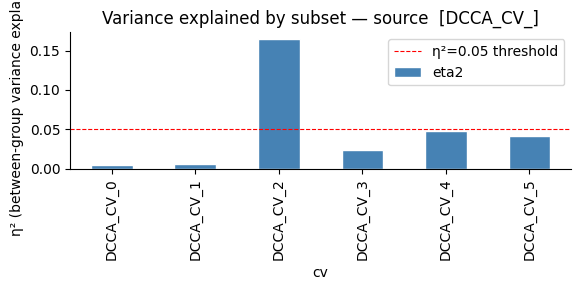

In [56]:
df_var_gex = compute_eta2_per_cv(mdata, dim_cca, composition_cols, cv_prefix="DCCA_CV_")

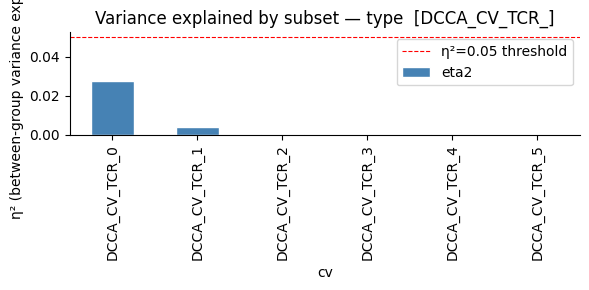

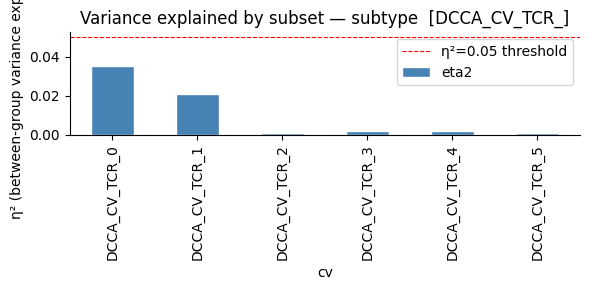

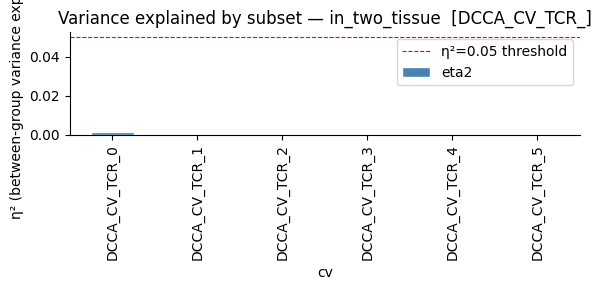

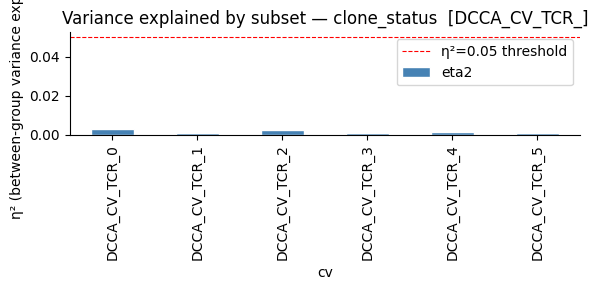

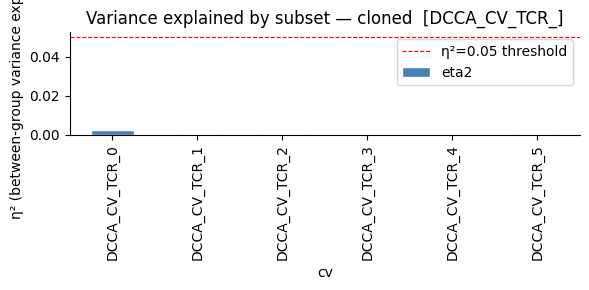

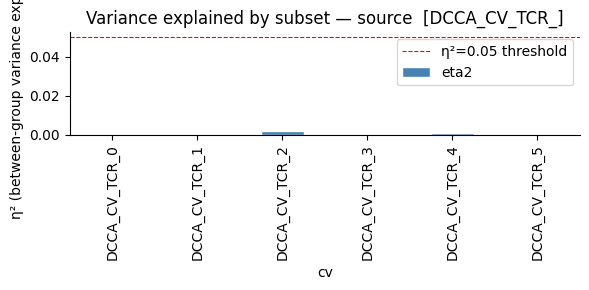

In [57]:
df_var_tcr = compute_eta2_per_cv(mdata, dim_cca, composition_cols, cv_prefix="DCCA_CV_TCR_")

In [58]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

records_ovr = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    # only run on columns that passed Step 1 FDR
    sig_cols = df_stats[
        (df_stats['cv'] == col) & (df_stats['pval_fdr'] < 0.05)
    ]['obs_col'].tolist()

    for c in sig_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)
        s = scores.loc[shared]
        g = labels.loc[shared]

        for cat_val in g.unique():
            in_group  = s[g == cat_val].values
            out_group = s[g != cat_val].values  # all rest

            if len(in_group) < 3 or len(out_group) < 3:
                continue

            U, p = mannwhitneyu(in_group, out_group, alternative='two-sided')

            # rank-biserial correlation as effect size
            rbc = 1 - (2 * U) / (len(in_group) * len(out_group))

            # median difference
            median_diff = np.median(in_group) - np.median(out_group)

            records_ovr.append(dict(
                cv          = col,
                obs_col     = c,
                category    = cat_val,
                n_in        = len(in_group),
                n_out       = len(out_group),
                U           = U,
                rbc         = rbc,
                median_diff = median_diff,
                pval        = p,
            ))

df_ovr = pd.DataFrame(records_ovr)
_, df_ovr['pval_fdr'], _, _ = multipletests(df_ovr['pval'], method='fdr_bh')
df_ovr = df_ovr.sort_values(['cv', 'pval_fdr'])

print(df_ovr[df_ovr['pval_fdr'] < 0.05])

                cv        obs_col              category   n_in  n_out  \
0    DCCA_CV_TCR_0           type                   CD4  20010   7149   
1    DCCA_CV_TCR_0           type                   CD8   7149  20010   
6    DCCA_CV_TCR_0        subtype         CD8_Trm_exh_L   1830  25329   
8    DCCA_CV_TCR_0        subtype               CD8_Tem   1885  25274   
13   DCCA_CV_TCR_0        subtype             CD8_KLRB1    447  26712   
..             ...            ...                   ...    ...    ...   
147  DCCA_CV_TCR_5  in_two_tissue                  True   1411  25748   
157  DCCA_CV_TCR_5         source                 Tumor  14220  12939   
160  DCCA_CV_TCR_5         cloned                  True   4381  22778   
161  DCCA_CV_TCR_5         cloned                 False  22778   4381   
149  DCCA_CV_TCR_5   clone_status  NAT_singleSite_clone   1094  26065   

              U       rbc  median_diff           pval       pval_fdr  
0    86205682.5 -0.205240     0.171866  9.087084e-14

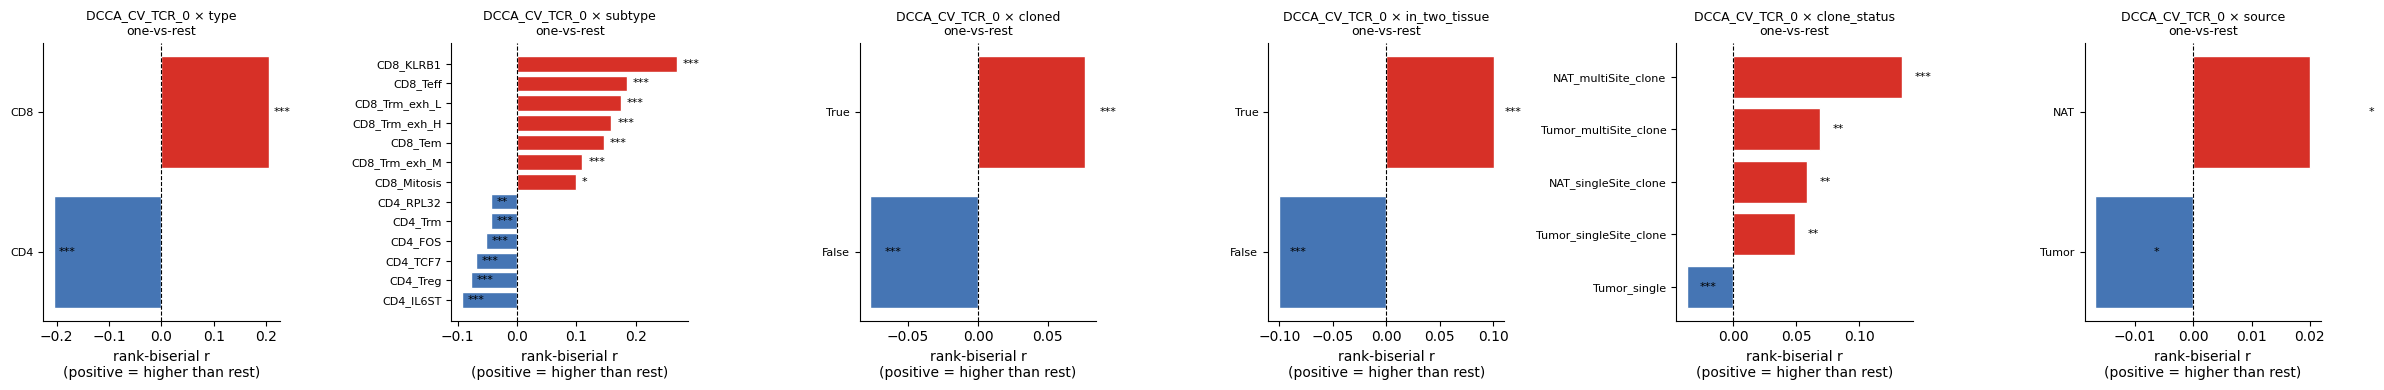

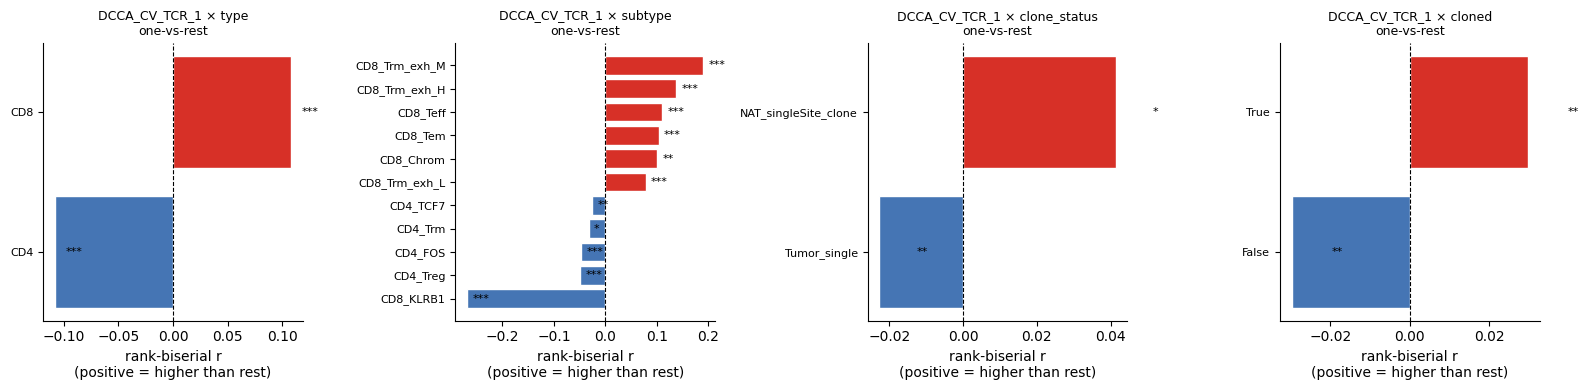

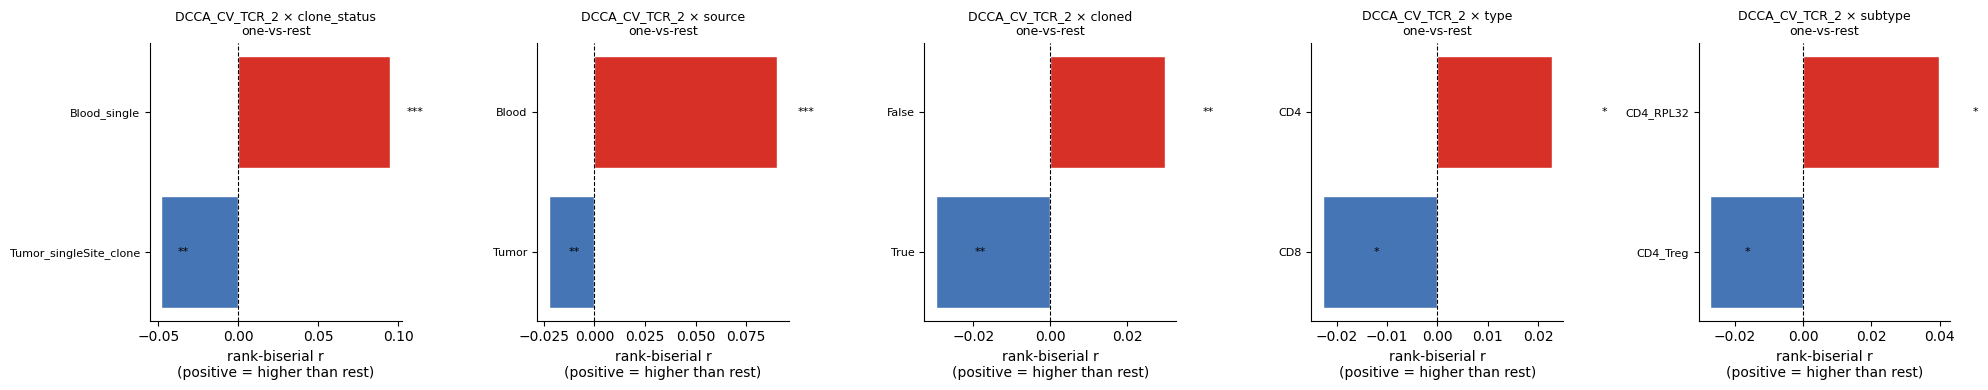

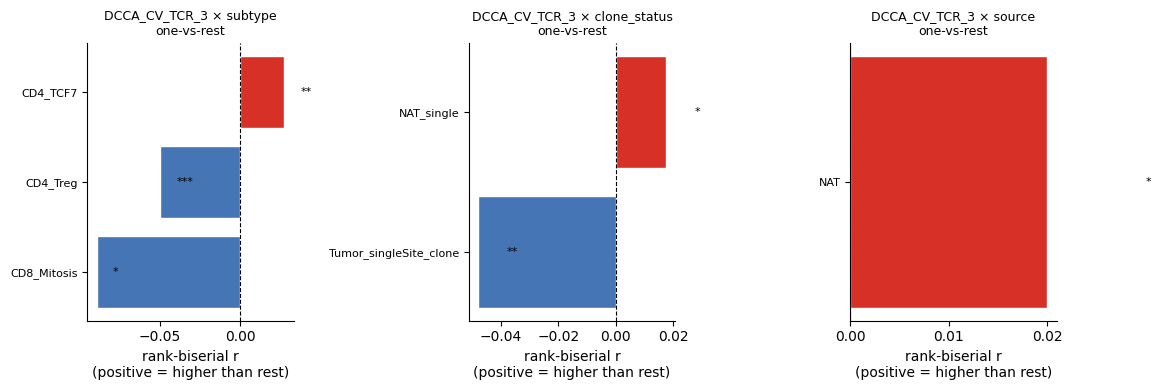

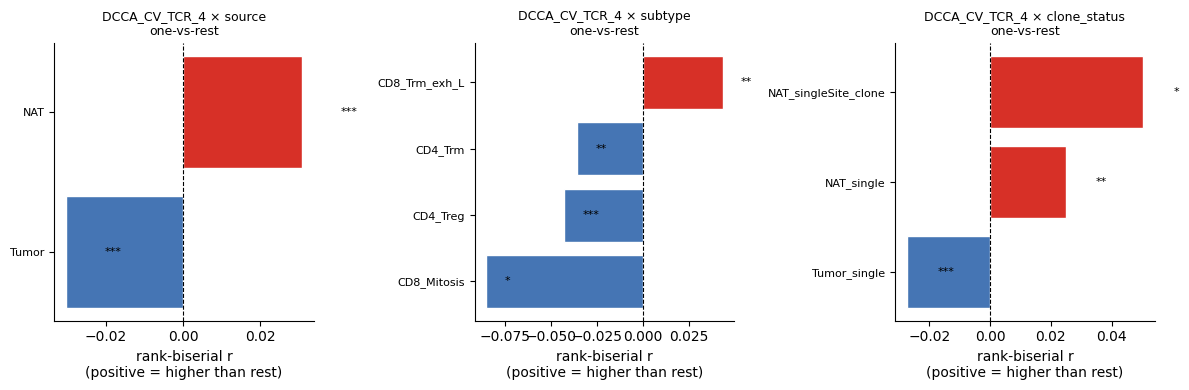

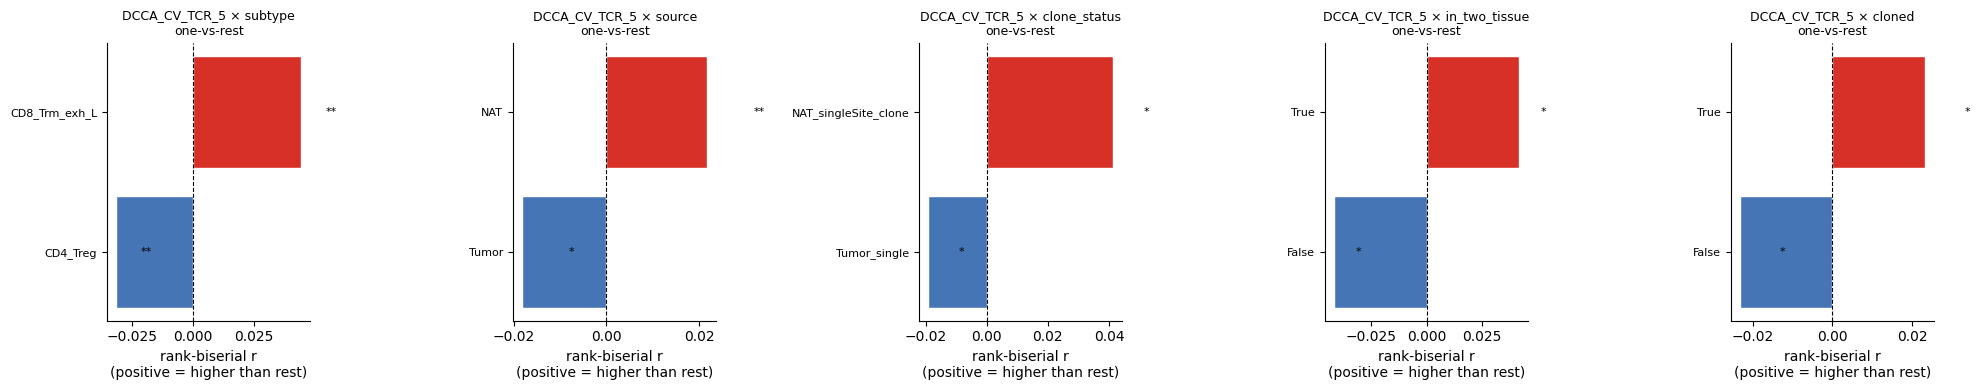

In [59]:
for i in range(dim_cca):
    col = CV_from + str(i)
    sub = df_ovr[
        (df_ovr['cv'] == col) & (df_ovr['pval_fdr'] < 0.05)
    ]

    if sub.empty:
        continue

    sig_cols = sub['obs_col'].unique()
    fig, axes = plt.subplots(1, len(sig_cols),
                              figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        plot_df = sub[sub['obs_col'] == c].sort_values('rbc')

        colors = ['#d73027' if v > 0 else '#4575b4'
                  for v in plot_df['rbc']]

        ax.barh(range(len(plot_df)), plot_df['rbc'],
                color=colors, edgecolor='white')
        ax.set_yticks(range(len(plot_df)))
        ax.set_yticklabels(plot_df['category'], fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('rank-biserial r\n(positive = higher than rest)')
        ax.set_title(f'{col} × {c}\none-vs-rest', fontsize=9)

        # mark FDR significance
        for j, (_, row) in enumerate(plot_df.iterrows()):
            stars = ('***' if row.pval_fdr < 0.001 else
                     '**'  if row.pval_fdr < 0.01  else
                     '*'   if row.pval_fdr < 0.05  else '')
            ax.text(row.rbc + 0.01, j, stars, va='center', fontsize=8)

        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    #plt.savefig(f'{col}_ovr.png', bbox_inches='tight')
    plt.show()

## TCR Canonical Variate Distributions: vdjdb_match True vs False

Compare `DCCA_CV_TCR_0` and `DCCA_CV_TCR_1` distributions across the two `vdjdb_match` subsets (True = CDR3 hit in VDJdb, False = no hit). Violin plots show the empirical distributions; KL divergence quantifies how far apart they are.

vdjdb_match=True : 4429 cells
vdjdb_match=False: 22730 cells


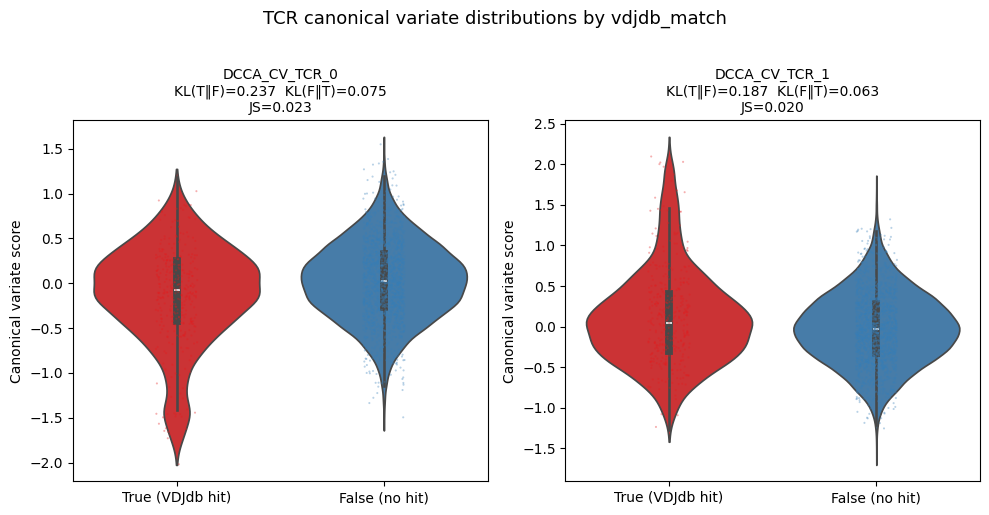


KL-divergence summary (KDE-based, 500-point grid):
           CV  KL_True_vs_False  KL_False_vs_True     JS
DCCA_CV_TCR_0            0.2371            0.0746 0.0232
DCCA_CV_TCR_1            0.1866            0.0630 0.0198


In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.special import rel_entr

# ── 1. Propagate vdjdb_match into gex.obs ───────────────────────────────────
# vdjdb_match lives in mdata.obs; DCCA scores live in mdata['gex'].obs.
# Align on shared index (cells present in gex modality).
gex_obs = mdata['gex'].obs.copy()
if 'vdjdb_match' not in gex_obs.columns:
    gex_obs['vdjdb_match'] = mdata.obs.loc[gex_obs.index, 'vdjdb_match']
    mdata['gex'].obs['vdjdb_match'] = gex_obs['vdjdb_match']

# ── 2. Build a tidy DataFrame for the two TCR CVs ───────────────────────────
tcr_cv_cols = ['DCCA_CV_TCR_0', 'DCCA_CV_TCR_1']
plot_df = mdata['gex'].obs[tcr_cv_cols + ['vdjdb_match']].dropna()
plot_df['vdjdb_match'] = plot_df['vdjdb_match'].map({True: 'True (VDJdb hit)',
                                                      False: 'False (no hit)'})

n_true  = (plot_df['vdjdb_match'] == 'True (VDJdb hit)').sum()
n_false = (plot_df['vdjdb_match'] == 'False (no hit)').sum()
print(f"vdjdb_match=True : {n_true} cells")
print(f"vdjdb_match=False: {n_false} cells")

# ── 3. KL divergence helper (KDE-based, symmetric Jensen-Shannon) ────────────
def kl_kde(a, b, n_pts=500):
    """One-sided KL(P || Q) using KDE.  Returns (KL_PQ, KL_QP, JS)."""
    lo = min(a.min(), b.min()) - 0.5
    hi = max(a.max(), b.max()) + 0.5
    xs = np.linspace(lo, hi, n_pts)

    kde_a = gaussian_kde(a)
    kde_b = gaussian_kde(b)
    p = kde_a(xs);  p /= p.sum()
    q = kde_b(xs);  q /= q.sum()

    eps = 1e-10
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)

    kl_pq = float(rel_entr(p, q).sum())   # KL(True || False)
    kl_qp = float(rel_entr(q, p).sum())   # KL(False || True)
    m = 0.5 * (p + q)
    js  = 0.5 * rel_entr(p, m).sum() + 0.5 * rel_entr(q, m).sum()
    return kl_pq, kl_qp, float(js)

# ── 4. Violin plots + KL annotation ─────────────────────────────────────────
palette = {'True (VDJdb hit)': '#e41a1c', 'False (no hit)': '#377eb8'}
order   = ['True (VDJdb hit)', 'False (no hit)']

fig, axes = plt.subplots(1, len(tcr_cv_cols), figsize=(5 * len(tcr_cv_cols), 5))

kl_results = {}
for ax, col in zip(axes, tcr_cv_cols):
    sns.violinplot(
        data=plot_df, x='vdjdb_match', y=col,
        order=order, palette=palette,
        inner='box', cut=0, ax=ax,
    )
    # overlay individual points (downsampled for speed)
    sub = plot_df.sample(min(len(plot_df), 2000), random_state=42)
    sns.stripplot(
        data=sub, x='vdjdb_match', y=col,
        order=order, palette=palette,
        size=1.5, alpha=0.35, jitter=True, ax=ax,
    )

    vals_true  = plot_df.loc[plot_df['vdjdb_match'] == 'True (VDJdb hit)',  col].values
    vals_false = plot_df.loc[plot_df['vdjdb_match'] == 'False (no hit)', col].values
    kl_pq, kl_qp, js = kl_kde(vals_true, vals_false)
    kl_results[col] = dict(KL_True_vs_False=kl_pq, KL_False_vs_True=kl_qp, JS=js)

    ax.set_title(f'{col}\nKL(T‖F)={kl_pq:.3f}  KL(F‖T)={kl_qp:.3f}\nJS={js:.3f}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Canonical variate score')

fig.suptitle('TCR canonical variate distributions by vdjdb_match', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 5. Summary table ─────────────────────────────────────────────────────────
kl_df = pd.DataFrame(kl_results).T.rename_axis('CV').reset_index()
print("\nKL-divergence summary (KDE-based, 500-point grid):")
print(kl_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


## KL divergence across all cats

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.special import rel_entr

# ── reuse kl_kde from cell above ────────────────────────────────────────────
# (already defined; re-defined here for standalone execution)
def kl_kde(a, b, n_pts=500):
    """KDE-based KL divergences + Jensen-Shannon.  Returns (KL_P‖Q, KL_Q‖P, JS)."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan, np.nan, np.nan
    lo = min(a.min(), b.min()) - 0.5
    hi = max(a.max(), b.max()) + 0.5
    xs = np.linspace(lo, hi, n_pts)
    p = gaussian_kde(a)(xs);  p /= p.sum()
    q = gaussian_kde(b)(xs);  q /= q.sum()
    eps = 1e-10
    p, q = np.clip(p, eps, None), np.clip(q, eps, None)
    kl_pq = float(rel_entr(p, q).sum())
    kl_qp = float(rel_entr(q, p).sum())
    m     = 0.5 * (p + q)
    js    = float(0.5 * rel_entr(p, m).sum() + 0.5 * rel_entr(q, m).sum())
    return kl_pq, kl_qp, js

# ── config ───────────────────────────────────────────────────────────────────
composition_cols = ['type', 'subtype', 'in_two_tissue', 'clone_status', 'cloned', 'source']
tcr_cv_cols      = ['DCCA_CV_TCR_0', 'DCCA_CV_TCR_1', 'DCCA_CV_TCR_2', 'DCCA_CV_TCR_3', 'DCCA_CV_TCR_4']
MIN_CELLS        = 10          # skip labels with too few cells

# ── pull everything into one flat DataFrame ──────────────────────────────────
base = mdata['gex'].obs[tcr_cv_cols].copy()
for col in composition_cols:
    if col in mdata['gex'].obs.columns:
        base[col] = mdata['gex'].obs[col]
    elif col in mdata.obs.columns:
        base[col] = mdata.obs.loc[base.index, col]

# ── one-vs-rest KL for every (obs_col, label, cv) triple ────────────────────
records = []
for obs_col in composition_cols:
    if obs_col not in base.columns:
        continue
    labels = base[obs_col].dropna().astype(str).unique()
    for label in labels:
        mask_in = base[obs_col].astype(str) == label
        for cv in tcr_cv_cols:
            vals_all  = base[cv].dropna()
            vals_in   = base.loc[mask_in & base[cv].notna(), cv].values
            vals_rest = base.loc[~mask_in & base[cv].notna(), cv].values

            if len(vals_in) < MIN_CELLS or len(vals_rest) < MIN_CELLS:
                continue

            kl_pq, kl_qp, js = kl_kde(vals_in, vals_rest)
            records.append(dict(
                obs_col=obs_col, label=label, cv=cv,
                n_in=len(vals_in), n_rest=len(vals_rest),
                KL_in_vs_rest=kl_pq, KL_rest_vs_in=kl_qp, JS=js,
            ))

df_kl = pd.DataFrame(records).sort_values('JS', ascending=False).reset_index(drop=True)
print(f"Total (obs_col, label, cv) combinations tested: {len(df_kl)}")
print("\nTop 10 by Jensen-Shannon divergence:")
print(df_kl.head(10).to_string(index=False,
      float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# ── violin plots for top 3 ───────────────────────────────────────────────────
import math
k = 10
topk = df_kl.dropna(subset=['JS']).head(k)

Total (obs_col, label, cv) combinations tested: 160

Top 10 by Jensen-Shannon divergence:
     obs_col                  label            cv  n_in  n_rest  KL_in_vs_rest  KL_rest_vs_in     JS
     subtype              CD8_KLRB1 DCCA_CV_TCR_0   447   26712         0.6778         0.2760 0.0854
     subtype              CD8_KLRB1 DCCA_CV_TCR_1   447   26712         0.5815         0.2525 0.0778
clone_status Blood_singleSite_clone DCCA_CV_TCR_2    20   27139         0.0759         0.1406 0.0217
        type                    CD4 DCCA_CV_TCR_0 20010    7149         0.0676         0.0789 0.0177
        type                    CD8 DCCA_CV_TCR_0  7149   20010         0.0789         0.0676 0.0177
clone_status Blood_singleSite_clone DCCA_CV_TCR_0    20   27139         0.0797         0.0592 0.0166
clone_status Blood_singleSite_clone DCCA_CV_TCR_1    20   27139         0.0748         0.0599 0.0158
     subtype          CD8_Trm_exh_M DCCA_CV_TCR_1   636   26523         0.0744         0.0601 0.0156
 

In [67]:
topk

,obs_col,label,cv,n_in,n_rest,KL_in_vs_rest,KL_rest_vs_in,JS
0,subtype,CD8_KLRB1,DCCA_CV_TCR_0,447,26712,0.677838,0.276039,0.085387
1,subtype,CD8_KLRB1,DCCA_CV_TCR_1,447,26712,0.581481,0.252480,0.077774
2,clone_status,Blood_singleSite_clone,DCCA_CV_TCR_2,20,27139,0.075898,0.140644,0.021676
3,type,CD4,DCCA_CV_TCR_0,20010,7149,0.067564,0.078894,0.017652
4,type,CD8,DCCA_CV_TCR_0,7149,20010,0.078894,0.067564,0.017652
5,clone_status,Blood_singleSite_clone,DCCA_CV_TCR_0,20,27139,0.079697,0.059243,0.016567
6,clone_status,Blood_singleSite_clone,DCCA_CV_TCR_1,20,27139,0.074751,0.059893,0.015821
7,subtype,CD8_Trm_exh_M,DCCA_CV_TCR_1,636,26523,0.074387,0.060123,0.015553
8,subtype,CD8_Teff,DCCA_CV_TCR_0,794,26365,0.054747,0.051435,0.013130
9,clone_status,Blood_multiSite_clone,DCCA_CV_TCR_1,71,27088,0.056393,0.048947,0.012794


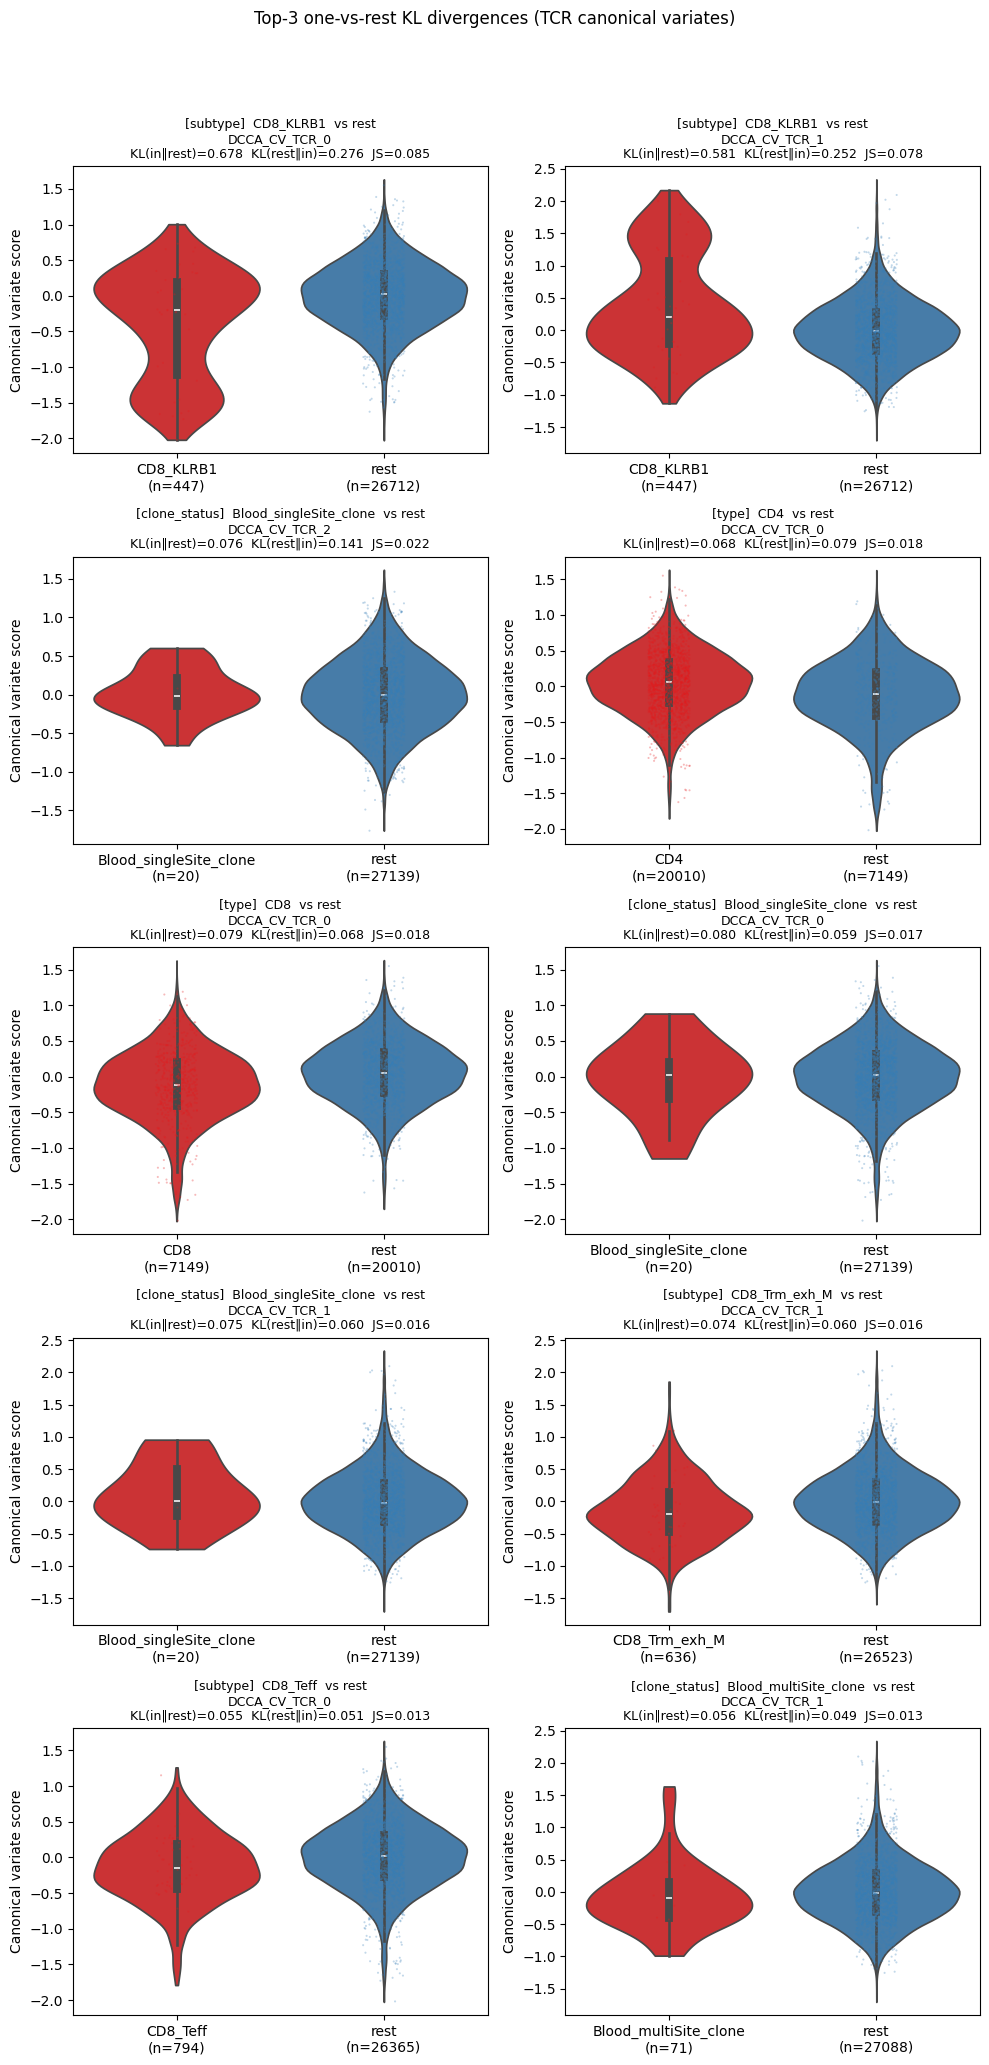

In [68]:

col = 2
row = math.ceil(k / 2)
fig, axes = plt.subplots(row, col, figsize=(col * 5, row * 4))

for ax, (_, row) in zip(axes.flatten(), topk.iterrows()):
    obs_col = row['obs_col']
    label   = row['label']
    cv      = row['cv']

    col_data = base[obs_col].astype(str)
    group_label  = f"{label}\n(n={row['n_in']})"
    rest_label   = f"rest\n(n={row['n_rest']})"

    vplot_df = base[[cv]].copy()
    vplot_df['group'] = np.where(col_data == label, group_label, rest_label)
    vplot_df = vplot_df.dropna(subset=[cv])

    order = [group_label, rest_label]
    palette = {group_label: '#e41a1c', rest_label: '#377eb8'}

    sns.violinplot(
        data=vplot_df, x='group', y=cv,
        order=order, palette=palette,
        inner='box', cut=0, ax=ax,
    )
    sub = vplot_df.sample(min(len(vplot_df), 2000), random_state=42)
    sns.stripplot(
        data=sub, x='group', y=cv,
        order=order, palette=palette,
        size=1.5, alpha=0.3, jitter=True, ax=ax,
    )

    ax.set_title(
        f"[{obs_col}]  {label}  vs rest\n{cv}\n"
        f"KL(in‖rest)={row['KL_in_vs_rest']:.3f}  "
        f"KL(rest‖in)={row['KL_rest_vs_in']:.3f}  JS={row['JS']:.3f}",
        fontsize=9,
    )
    ax.set_xlabel('')
    ax.set_ylabel('Canonical variate score')

fig.suptitle('Top-3 one-vs-rest KL divergences (TCR canonical variates)', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

### subseting strategies

In [69]:
aa

NameError: name 'aa' is not defined

In [ ]:
mdata

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# ── Config ──────────────────────────────────────────────────────────────────
composition_cols = ['vdjdb_match']

# Private dims: CCA components 3 & 4 (0-indexed: 2, 3)
private_dims = [0,1]

# Build private feature matrix from both CCA views
gex_private = np.stack([
    mdata['gex'].obs[f'DCCA_CV_{i}'] for i in private_dims
], axis=1)

tcr_private = np.stack([
    mdata['gex'].obs[f'DCCA_CV_TCR_{i}'] for i in private_dims
], axis=1)

X_private = np.hstack([gex_private, tcr_private])  # (n_cells, 4)
feature_names = [f'GEX_CV{i}' for i in private_dims] + \
                [f'TCR_CV{i}' for i in private_dims]

obs = mdata['gex'].obs.copy()

In [ ]:
# ── Per-label Decision Tree discrimination ───────────────────────────────────
results = []

for col in composition_cols:
    if col not in obs.columns:
        print(f"Skipping {col} — not found in obs")
        continue

    # Encode labels, drop NaN
    valid_mask = obs[col].notna()
    y_raw = obs.loc[valid_mask, col]
    X_valid = X_private[valid_mask]

    if y_raw.nunique() < 2:
        print(f"Skipping {col} — only one class")
        continue

    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    # Global discrimination score
    dt = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=30,   # avoid tiny spurious leaves
        random_state=42
    )
    global_score = cross_val_score(dt, X_valid, y, cv=5, scoring='balanced_accuracy').mean()

    # ── Find discriminative subsets via leaf purity ──────────────────────────
    dt_full = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)
    dt_full.fit(X_valid, y)
    leaf_ids = dt_full.apply(X_valid)

    leaf_stats = []
    for leaf in np.unique(leaf_ids):
        mask = leaf_ids == leaf
        n = mask.sum()
        y_leaf = y[mask]
        classes, counts = np.unique(y_leaf, return_counts=True)
        purity = counts.max() / n
        dominant_class = le.inverse_transform([classes[counts.argmax()]])[0]

        leaf_stats.append({
            'leaf': leaf,
            'n_cells': n,
            'purity': purity,
            'dominant_class': dominant_class,
            'n_classes': len(classes)
        })

    leaf_df = pd.DataFrame(leaf_stats).sort_values('purity', ascending=False)

    # Flag discriminative leaves: purity > 0.75, size > 30
    disc_leaves  = leaf_df[(leaf_df['purity'] > 0.75) & (leaf_df['n_cells'] > 30)]
    disc_cell_idx = np.where(valid_mask)[0][np.isin(leaf_ids, disc_leaves['leaf'].values)]

    results.append({
        'col':              col,
        'global_bal_acc':   global_score,
        'n_disc_leaves':    len(disc_leaves),
        'n_disc_cells':     len(disc_cell_idx),
        'pct_disc_cells':   len(disc_cell_idx) / valid_mask.sum() * 100,
        'top_leaf_purity':  leaf_df['purity'].iloc[0],
        'disc_leaf_df':     leaf_df,
        'disc_cell_idx':    disc_cell_idx,
        'tree':             dt_full,
        'le':               le,
        'valid_mask':       valid_mask
    })

    print(f"\n{'='*55}")
    print(f"  {col}  |  global balanced acc: {global_score:.3f}")
    print(f"  Discriminative leaves (purity>0.75, n>30): {len(disc_leaves)}")
    print(f"  Cells in discriminative subsets: {len(disc_cell_idx)} "
          f"({len(disc_cell_idx)/valid_mask.sum()*100:.1f}%)")
    print(disc_leaves[['n_cells','purity','dominant_class']].to_string(index=False))

In [ ]:
# ── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'column':           r['col'],
    'global_bal_acc':   round(r['global_bal_acc'], 3),
    'n_disc_leaves':    r['n_disc_leaves'],
    'n_disc_cells':     r['n_disc_cells'],
    'pct_disc_cells':   round(r['pct_disc_cells'], 1),
    'top_leaf_purity':  round(r['top_leaf_purity'], 3),
} for r in results]).sort_values('global_bal_acc', ascending=False)

print("\n── Summary ──")
print(summary.to_string(index=False))

In [ ]:
# ── Annotate discriminative cells back into obs ──────────────────────────────
for r in results:
    col_name = f'disc_subset_{r["col"]}'
    mdata['gex'].obs[col_name] = 'non_discriminative'
    mdata['gex'].obs.iloc[r['disc_cell_idx'], 
        mdata['gex'].obs.columns.get_loc(col_name)] = f'disc_{r["col"]}'

# ── Print tree rules for best column ────────────────────────────────────────
if results:
    best = max(results, key=lambda x: x['global_bal_acc'])
    print(f"\n── Tree rules for best column: {best['col']} ──")
    print(export_text(best['tree'], feature_names=feature_names))

# Quality for fusion

### Contribution scores

In [ ]:
# 
# df_cca_weights = pd.DataFrame(cca.y_weights_)
# # df_cca_weights.to_csv(filename + 'TCR_weights.csv')
# cca_weights_abs = df_cca_weights.abs()

# cca_weights_abs_beta = cca_weights_abs.iloc[0:596].sum() + cca_weights_abs.iloc[1191:1128].sum()
# cca_weights_abs_alpha = cca_weights_abs.iloc[596:596+596].sum() + cca_weights_abs.iloc[1128:1374].sum()
# df_cca_weights_abs_sum = pd.DataFrame(
#     [cca_weights_abs_beta, cca_weights_abs_alpha],
#     index=['beta', 'alpha']
# )

# df_cca_weights_abs_sum = df_cca_weights_abs_sum / df_cca_weights_abs_sum.sum(axis=0)
# df_cca_weights_abs_sum


## metrics comparison between subsets in mdata

In [ ]:
aa

In [ ]:
# 4. Visualize — PCA of CV space colored by subset
# "Where do subsets sit in the joint CV space?"

from sklearn.decomposition import PCA

cv_matrix = mdata['gex'].obs[cv_cols].dropna()
pca = PCA(n_components=2)
embedding = pca.fit_transform(cv_matrix.values)
embed_df  = pd.DataFrame(embedding, index=cv_matrix.index,
                         columns=['PC1', 'PC2'])

for c in composition_cols:
    labels = mdata['gex'].obs.loc[cv_matrix.index, c]
    embed_df[c] = labels.values

    fig, ax = plt.subplots(figsize=(6, 5))
    for cat_val, grp in embed_df.groupby(c):
        ax.scatter(grp['PC1'], grp['PC2'], label=cat_val, alpha=0.5, s=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'CV space — colored by {c}')
    ax.legend(bbox_to_anchor=(1.05, 1), fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    #plt.savefig(f'cv_pca_{c}.png', bbox_inches='tight')
    plt.show()

In [ ]:
aa

## logit regression

In [ ]:
### Logistic Regression per subtype: predict clone_status using DCCA canonical variates ###
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
import torch
import torch.nn as nn

tg = obs_select
g1, g2 = tg[0], tg[1]

cs = obs_select.astype(str).to_numpy()
sub = mdata.obs['Annotation_minor_subset'].astype(str).to_numpy()
in_groups = np.isin(cs, tg)

y_all = (cs == g1).astype(int)

subtypes = sorted(set(sub[in_groups]))

class WeightedLogistic(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.ones(n_features))
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x * self.feature_weights).squeeze(-1)

lr_results = []

for st in subtypes:
    st_mask = sub == st
    mask_tr = train_mask & in_groups & st_mask
    mask_te = test_mask & in_groups & st_mask

    X_tr = view_tcr_c[mask_tr]
    X_te = view_tcr_c[mask_te]
    y_tr = y_all[mask_tr]
    y_te = y_all[mask_te]

    if X_tr.shape[0] < 10 or X_te.shape[0] < 4:
        continue
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        continue

    ros = RandomOverSampler(random_state=42)
    X_tr_bal, y_tr_bal = ros.fit_resample(X_tr, y_tr)

    # Trainable-weight logistic
    wlr_epochs = 200
    X_tr_t = torch.tensor(X_tr_bal, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_bal, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    wlr = WeightedLogistic(X_tr_t.shape[1])
    optimizer = torch.optim.Adam(wlr.parameters(), lr=1e-2)
    loss_fn = nn.BCEWithLogitsLoss()

    wlr.train()
    for epoch in range(wlr_epochs):
        optimizer.zero_grad()
        loss_fn(wlr(X_tr_t), y_tr_t).backward()
        optimizer.step()

    wlr.eval()
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(wlr(X_te_t)).numpy()
        y_pred = (y_pred_proba >= 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    try:
        auc = roc_auc_score(y_te, y_pred_proba)
    except ValueError:
        auc = np.nan

    learned_w = wlr.feature_weights.detach().numpy()

    lr_results.append({
        'subtype': st,
        'n_train': X_tr_bal.shape[0],
        'n_test': X_te.shape[0],
        'accuracy': acc,
        'roc_auc': auc,
        'feature_weights': learned_w.tolist(),
    })

    print(f"\n{'='*60}")
    print(f"Subtype: {st}  (train={X_tr_bal.shape[0]}, test={X_te.shape[0]})")
    print(f"{'='*60}")
    print(f"Feature weights: {learned_w}")
    print(f"Accuracy: {acc:.4f}   ROC AUC: {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=[g2, g1], zero_division=0))

lr_results_df = pd.DataFrame(lr_results)
lr_results_df
